In [ ]:
import os, base64
from dotenv import load_dotenv
from snowflake import connector as snowflake_connector
from snowflake.snowpark.session import Session

load_dotenv('.env')

# creds = {
#     'account':     os.getenv('SNOWFLAKE_ACCOUNT'),
#     'warehouse':   os.getenv('SNOWFLAKE_WAREHOUSE'),
#     'role':        os.getenv('SNOWFLAKE_ROLE'),
#     'user':        os.getenv('SNOWFLAKE_USERNAME'),
#     'private_key': base64.b64decode(os.getenv('SNOWFLAKE_PRIVATE_KEY')),
# }
# print(creds)
# # 1. The classic connector — for raw SQL + polars.read_database
# snowflake_connection = snowflake_connector.connect(**creds)

snowflake_connection = snowflake_connector.connect(**{
     'account': os.getenv('SNOWFLAKE_ACCOUNT'),
     'warehouse': os.getenv('SNOWFLAKE_WAREHOUSE'),
     'role': os.getenv('SNOWFLAKE_ROLE'),
     'user': os.getenv('SNOWFLAKE_USERNAME'),
     'private_key': base64.b64decode(os.getenv('SNOWFLAKE_PRIVATE_KEY'))
})

# # 2. The Snowpark session — for the DataFrame API
snowpark_session = Session.builder.configs(creds).create()

In [ ]:
import polars as pl

(
    pl.read_database(
        """
        SELECT *
        FROM LISTED_INTERN_PROJECT.PROJECT_COMMON.BINNED_DATA
        LIMIT 10
        """,
        snowflake_connection,
    )
    # Snowflake returns ALL CAPS column names — normalize them
    .select(pl.all().name.to_lowercase())
)

qcode,publication_date,security,bin_start_time,gmt_offset_hours,open,high,low,close,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,bid_start,bid_end,ask_start,ask_end
str,date,str,time,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64
"""UG""",2021-02-05,"""WN2021H Comdty""",14:15:00,-6.0,200.375,200.40625,200.28125,200.34375,75.468687,68.109347,24,68,171,64,878,355,178,200.337842,200.323602,200.355292,200.375,200.3125,200.40625,200.34375
"""GM""",2021-06-22,"""OE2021U Comdty""",12:50:00,2.0,134.0,134.01,133.99,133.99,1615.601657,2484.679653,1865,2700,2489,1508,4999,2005,62,133.999946,133.99746,134.00746,134.0,133.99,134.01,134.0
"""GC""",2021-10-05,"""GC2021Z Comdty""",08:45:00,-4.0,1758.9,1759.9,1758.2,1758.3,7.86805,7.896997,1,8,7,6,804,-39,363,1759.093408,1758.855649,1758.981858,1758.9,1758.2,1759.0,1758.3
"""TT""",2021-08-31,"""TP2021U Index""",12:50:00,9.0,1952.5,1957.5,1952.0,1957.5,69.41374,69.347557,63,72,28,8,1174,856,274,1954.763203,1953.639358,1954.15775,1952.0,1957.0,1952.5,1957.5
"""HN""",2021-09-09,"""XU2021U Index""",11:35:00,8.0,15263.0,15272.0,15263.0,15269.0,23.225733,11.916113,4,14,8,13,537,36,282,15267.793296,15266.098943,15267.395643,15263.0,15267.0,15265.0,15270.0
"""FX""",2021-07-14,"""VG2021U Index""",12:25:00,2.0,4077.5,4080.0,4076.0,4077.5,149.49833,134.076733,110,76,229,190,2645,1481,176,4078.683554,4077.215973,4077.741842,4077.5,4077.5,4078.0,4078.0
"""TY""",2021-12-27,"""TY2022H Comdty""",09:50:00,-6.0,130.609375,130.625,130.59375,130.609375,1532.4901,1482.631473,1478,1940,1683,441,6229,579,370,130.613213,130.606847,130.622477,130.609375,130.609375,130.625,130.625
"""PI""",2021-04-12,"""XP2021M Index""",12:55:00,10.0,6938.0,6939.0,6936.0,6937.0,11.0354,9.184683,3,19,13,7,87,5,63,6936.954023,6936.536157,6937.60802,6938.0,6936.0,6939.0,6937.0
"""HG""",2021-10-28,"""HG2021Z Comdty""",05:05:00,-4.0,4.4385,4.443,4.4375,4.4395,3.40383,3.140397,3,4,3,2,176,9,104,4.439517,4.440269,4.441199,4.438,4.4385,4.439,4.4395


---

## Extract all tables → `data/raw/`

Pull the four tables from `LISTED_INTERN_PROJECT.PROJECT_COMMON` and save each as a CSV in `data/raw/`:

| Table | Description |
|---|---|
| `BINNED_DATA` | 5-minute bin OHLC + microstructure data for front-month contracts |
| `QCODE_MAPPING` | Curve identifier (`qcode`) descriptions |
| `SECURITY_META` | Meta information for all outright contracts |
| `TRADE_LIST` | Individual trade records |

Each table is read in full via the raw connector and written to `data/raw/<table>.csv`.

In [ ]:
# import polars as pl
# from pathlib import Path

# RAW_DIR = Path("data/raw")
# RAW_DIR.mkdir(parents=True, exist_ok=True)

# SCHEMA = "LISTED_INTERN_PROJECT.PROJECT_COMMON"
# TABLES = ["BINNED_DATA", "QCODE_MAPPING", "SECURITY_META", "TRADE_LIST"]

# for table in TABLES:
#     df = pl.read_database(
#         f"SELECT * FROM {SCHEMA}.{table}",
#         snowflake_connection,
#     ).select(pl.all().name.to_lowercase())  # normalize ALL CAPS column names

#     out_path = RAW_DIR / f"{table.lower()}.csv"
#     df.write_csv(out_path)
#     print(f"{table}: {df.shape[0]:,} rows x {df.shape[1]} cols -> {out_path}")


---

## Preview each table (direct from Snowflake)

Read a few rows of every table straight from `LISTED_INTERN_PROJECT.PROJECT_COMMON` (not from the CSVs) to sanity-check the structure.

In [ ]:
import polars as pl

pl.Config.set_tbl_cols(-1)  # show all columns

SCHEMA = "LISTED_INTERN_PROJECT.PROJECT_COMMON"
TABLES = ["BINNED_DATA", "QCODE_MAPPING", "SECURITY_META", "TRADE_LIST"]

for table in TABLES:
    df = pl.read_database(
        f"SELECT * FROM {SCHEMA}.{table} LIMIT 5",
        snowflake_connection,
    ).select(pl.all().name.to_lowercase())
    print(f"\n{'='*80}\n{table}  (showing 5 rows, {df.width} columns)\n{'='*80}")
    print(df)



BINNED_DATA  (showing 5 rows, 25 columns)
shape: (5, 25)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ qco ┆ pub ┆ sec ┆ bin ┆ gmt ┆ ope ┆ hig ┆ low ┆ clo ┆ twa ┆ twa ┆ bid ┆ bid ┆ ask ┆ ask ┆ vol ┆ sig ┆ tra ┆ vwa ┆ twa ┆ twa ┆ bid ┆ bid ┆ ask ┆ ask │
│ de  ┆ lic ┆ uri ┆ _st ┆ _of ┆ n   ┆ h   ┆ --- ┆ se  ┆ _bi ┆ _as ┆ _si ┆ _si ┆ _si ┆ _si ┆ ume ┆ ned ┆ de_ ┆ p   ┆ _bi ┆ _as ┆ _st ┆ _en ┆ _st ┆ _en │
│ --- ┆ ati ┆ ty  ┆ art ┆ fse ┆ --- ┆ --- ┆ f64 ┆ --- ┆ d_s ┆ k_s ┆ ze_ ┆ ze_ ┆ ze_ ┆ ze_ ┆ --- ┆ _vo ┆ cou ┆ --- ┆ d   ┆ k   ┆ art ┆ d   ┆ art ┆ d   │
│ str ┆ on_ ┆ --- ┆ _ti ┆ t_h ┆ f64 ┆ f64 ┆     ┆ f64 ┆ ize ┆ ize ┆ sta ┆ end ┆ sta ┆ end ┆ i32 ┆ lum ┆ nt  ┆ f64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│     ┆ dat ┆ str ┆ me  ┆ our ┆     ┆     ┆     ┆     ┆ --- ┆ --- ┆ rt  ┆ --- ┆ rt  ┆ --- ┆     ┆ e   ┆ --- ┆     ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 │
│     ┆ e   ┆     ┆ --- ┆ s   

---

## How does `TRADE_LIST` look?

Inspecting the table directly (queries below) shows:

- **Columns:** `security`, `date`, `trade_list`, `side`, `quantity` — 5 columns, ~790,776 rows.
- **It spans many days, not one.** Dates run from **2016-01-04 to 2026-04-30** (2,687 distinct trading days) across **3,445 distinct securities** (one per front-month contract over time).
- **Grain = exactly 6 rows per `(security, date)`.** Every security/day has one row for each combination of size bucket × side:

  | `trade_list` | `side` | typical qty (example day) |
  |---|---|---|
  | `small_buys`   | buy  | 333    |
  | `small_sells`  | sell | 333    |
  | `medium_buys`  | buy  | 3,330  |
  | `medium_sells` | sell | 3,330  |
  | `large_buys`   | buy  | 33,298 |
  | `large_sells`  | sell | 33,298 |

- The size buckets are roughly **10× apart** (small → medium → large), and on a given day the **buy and sell quantities mirror each other** within each bucket. So this isn't a log of actual market prints — it's a structured per-day, per-security **trade schedule** (how much you'd buy/sell in small/medium/large clips), keyed to a `(security, date)` you can join back to `BINNED_DATA` for execution prices.

The cells below reproduce these findings against Snowflake.

In [ ]:
TL = "LISTED_INTERN_PROJECT.PROJECT_COMMON.TRADE_LIST"

# Date span + coverage
print(pl.read_database(
    f"""SELECT MIN(date) AS first_date, MAX(date) AS last_date,
               COUNT(DISTINCT date) AS n_days,
               COUNT(DISTINCT security) AS n_securities,
               COUNT(*) AS n_rows
        FROM {TL}""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# The 6 categories
print(pl.read_database(
    f"""SELECT trade_list, side, COUNT(*) AS n, SUM(quantity) AS total_qty
        FROM {TL} GROUP BY 1, 2 ORDER BY 1, 2""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# One full security/day = exactly 6 rows
print(pl.read_database(
    f"""SELECT * FROM {TL}
        WHERE security = 'IK2026M Comdty' AND date = '2026-03-06'
        ORDER BY trade_list""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))


shape: (1, 5)
┌────────────┬────────────┬────────┬──────────────┬────────┐
│ first_date ┆ last_date  ┆ n_days ┆ n_securities ┆ n_rows │
│ ---        ┆ ---        ┆ ---    ┆ ---          ┆ ---    │
│ date       ┆ date       ┆ i64    ┆ i64          ┆ i32    │
╞════════════╪════════════╪════════╪══════════════╪════════╡
│ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         ┆ 790776 │
└────────────┴────────────┴────────┴──────────────┴────────┘
shape: (6, 4)
┌──────────────┬──────┬────────┬────────────┐
│ trade_list   ┆ side ┆ n      ┆ total_qty  │
│ ---          ┆ ---  ┆ ---    ┆ ---        │
│ str          ┆ str  ┆ i64    ┆ i64        │
╞══════════════╪══════╪════════╪════════════╡
│ large_buys   ┆ buy  ┆ 131796 ┆ 3026686292 │
│ large_sells  ┆ sell ┆ 131796 ┆ 3026686292 │
│ medium_buys  ┆ buy  ┆ 131796 ┆ 302668873  │
│ medium_sells ┆ sell ┆ 131796 ┆ 302668873  │
│ small_buys   ┆ buy  ┆ 131796 ┆ 30266773   │
│ small_sells  ┆ sell ┆ 131796 ┆ 30266773   │
└──────────────┴──────┴────────┴───────

---

## Does `BINNED_DATA` start before `TRADE_LIST`?

**No — the date spans are identical.** Both tables run **2016-01-04 → 2026-04-30** over the same **2,687 trading days** and the same **3,445 securities**. Neither leads the other; they're a matched pair, so every `(security, date)` in the trade schedule has price bins to execute against.

`BINNED_DATA` is ~13.05M rows across 50 qcodes, spread evenly at ~260 days / ~1.26M rows per year (2016–2025), plus a partial 2026 (85 days, through Apr 30).

In [ ]:
B = "LISTED_INTERN_PROJECT.PROJECT_COMMON.BINNED_DATA"

# Span comparison: BINNED_DATA vs TRADE_LIST
print(pl.read_database(
    f"""SELECT 'BINNED_DATA' AS tbl, MIN(publication_date) AS first_date, MAX(publication_date) AS last_date,
               COUNT(DISTINCT publication_date) AS n_days, COUNT(DISTINCT security) AS n_securities
        FROM {B}
        UNION ALL
        SELECT 'TRADE_LIST', MIN(date), MAX(date), COUNT(DISTINCT date), COUNT(DISTINCT security)
        FROM {TL}""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# BINNED_DATA rows by year
print(pl.read_database(
    f"""SELECT YEAR(publication_date) AS yr, COUNT(DISTINCT publication_date) AS n_days, COUNT(*) AS n_rows
        FROM {B} GROUP BY 1 ORDER BY 1""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))


shape: (2, 5)
┌─────────────┬────────────┬────────────┬────────┬──────────────┐
│ tbl         ┆ first_date ┆ last_date  ┆ n_days ┆ n_securities │
│ ---         ┆ ---        ┆ ---        ┆ ---    ┆ ---          │
│ str         ┆ date       ┆ date       ┆ i64    ┆ i64          │
╞═════════════╪════════════╪════════════╪════════╪══════════════╡
│ BINNED_DATA ┆ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         │
│ TRADE_LIST  ┆ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         │
└─────────────┴────────────┴────────────┴────────┴──────────────┘
shape: (11, 3)
┌──────┬────────┬─────────┐
│ yr   ┆ n_days ┆ n_rows  │
│ ---  ┆ ---    ┆ ---     │
│ i16  ┆ i64    ┆ i64     │
╞══════╪════════╪═════════╡
│ 2016 ┆ 260    ┆ 1264863 │
│ 2017 ┆ 260    ┆ 1260350 │
│ 2018 ┆ 260    ┆ 1261713 │
│ 2019 ┆ 260    ┆ 1261699 │
│ 2020 ┆ 261    ┆ 1267555 │
│ …    ┆ …      ┆ …       │
│ 2022 ┆ 260    ┆ 1265768 │
│ 2023 ┆ 260    ┆ 1261469 │
│ 2024 ┆ 261    ┆ 1267134 │
│ 2025 ┆ 260    ┆ 1261003 │
│ 2026 ┆ 85     ┆ 41270

---

## Average intraday volume profile per qcode

For each `(qcode, day)` the front-month contract's 5-minute bins are converted to a
**volume proportion** (`bin volume / that day's total volume`). Those daily profiles
are then averaged bin-by-bin across **all** trading days for the qcode, so each
qcode's curve sums to ~1.0 across the day.

`BINNED_DATA` already holds exactly **one security per `(qcode, date)`** — the
front-month contract — so no contract selection is required. The result is one
intraday profile per qcode: *share of the day's volume traded in each 5-min bin*.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

binned = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "volume"
)

# daily total volume, and trading-day count per qcode (the averaging denominator)
day_tot = binned.group_by("qcode", "publication_date").agg(
    pl.col("volume").sum().alias("day_volume")
)
n_days = (
    binned.select("qcode", "publication_date").unique()
    .group_by("qcode").agg(pl.len().alias("n_days"))
)

# per-day per-bin proportion -> average across days (missing bins count as 0,
# i.e. sum the daily proportions and divide by the qcode's total trading days)
profile = (
    binned.join(day_tot, on=["qcode", "publication_date"])
    .filter(pl.col("day_volume") > 0)
    .with_columns((pl.col("volume") / pl.col("day_volume")).alias("proportion"))
    .group_by("qcode", "bin_start_time")
    .agg(pl.col("proportion").sum().alias("sum_proportion"))
    .join(n_days, on="qcode")
    .with_columns((pl.col("sum_proportion") / pl.col("n_days")).alias("mean_proportion"))
    .with_columns(
        (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
         + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
    )
    .select("qcode", "bin_start_time", "minutes", "mean_proportion")
    .sort("qcode", "minutes")
)
profile.head()


qcode,bin_start_time,minutes,mean_proportion
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.038049
"""AZ""","""09:05:00.000000000""",545,0.022559
"""AZ""","""09:10:00.000000000""",550,0.017923
"""AZ""","""09:15:00.000000000""",555,0.016919
"""AZ""","""09:20:00.000000000""",560,0.01478


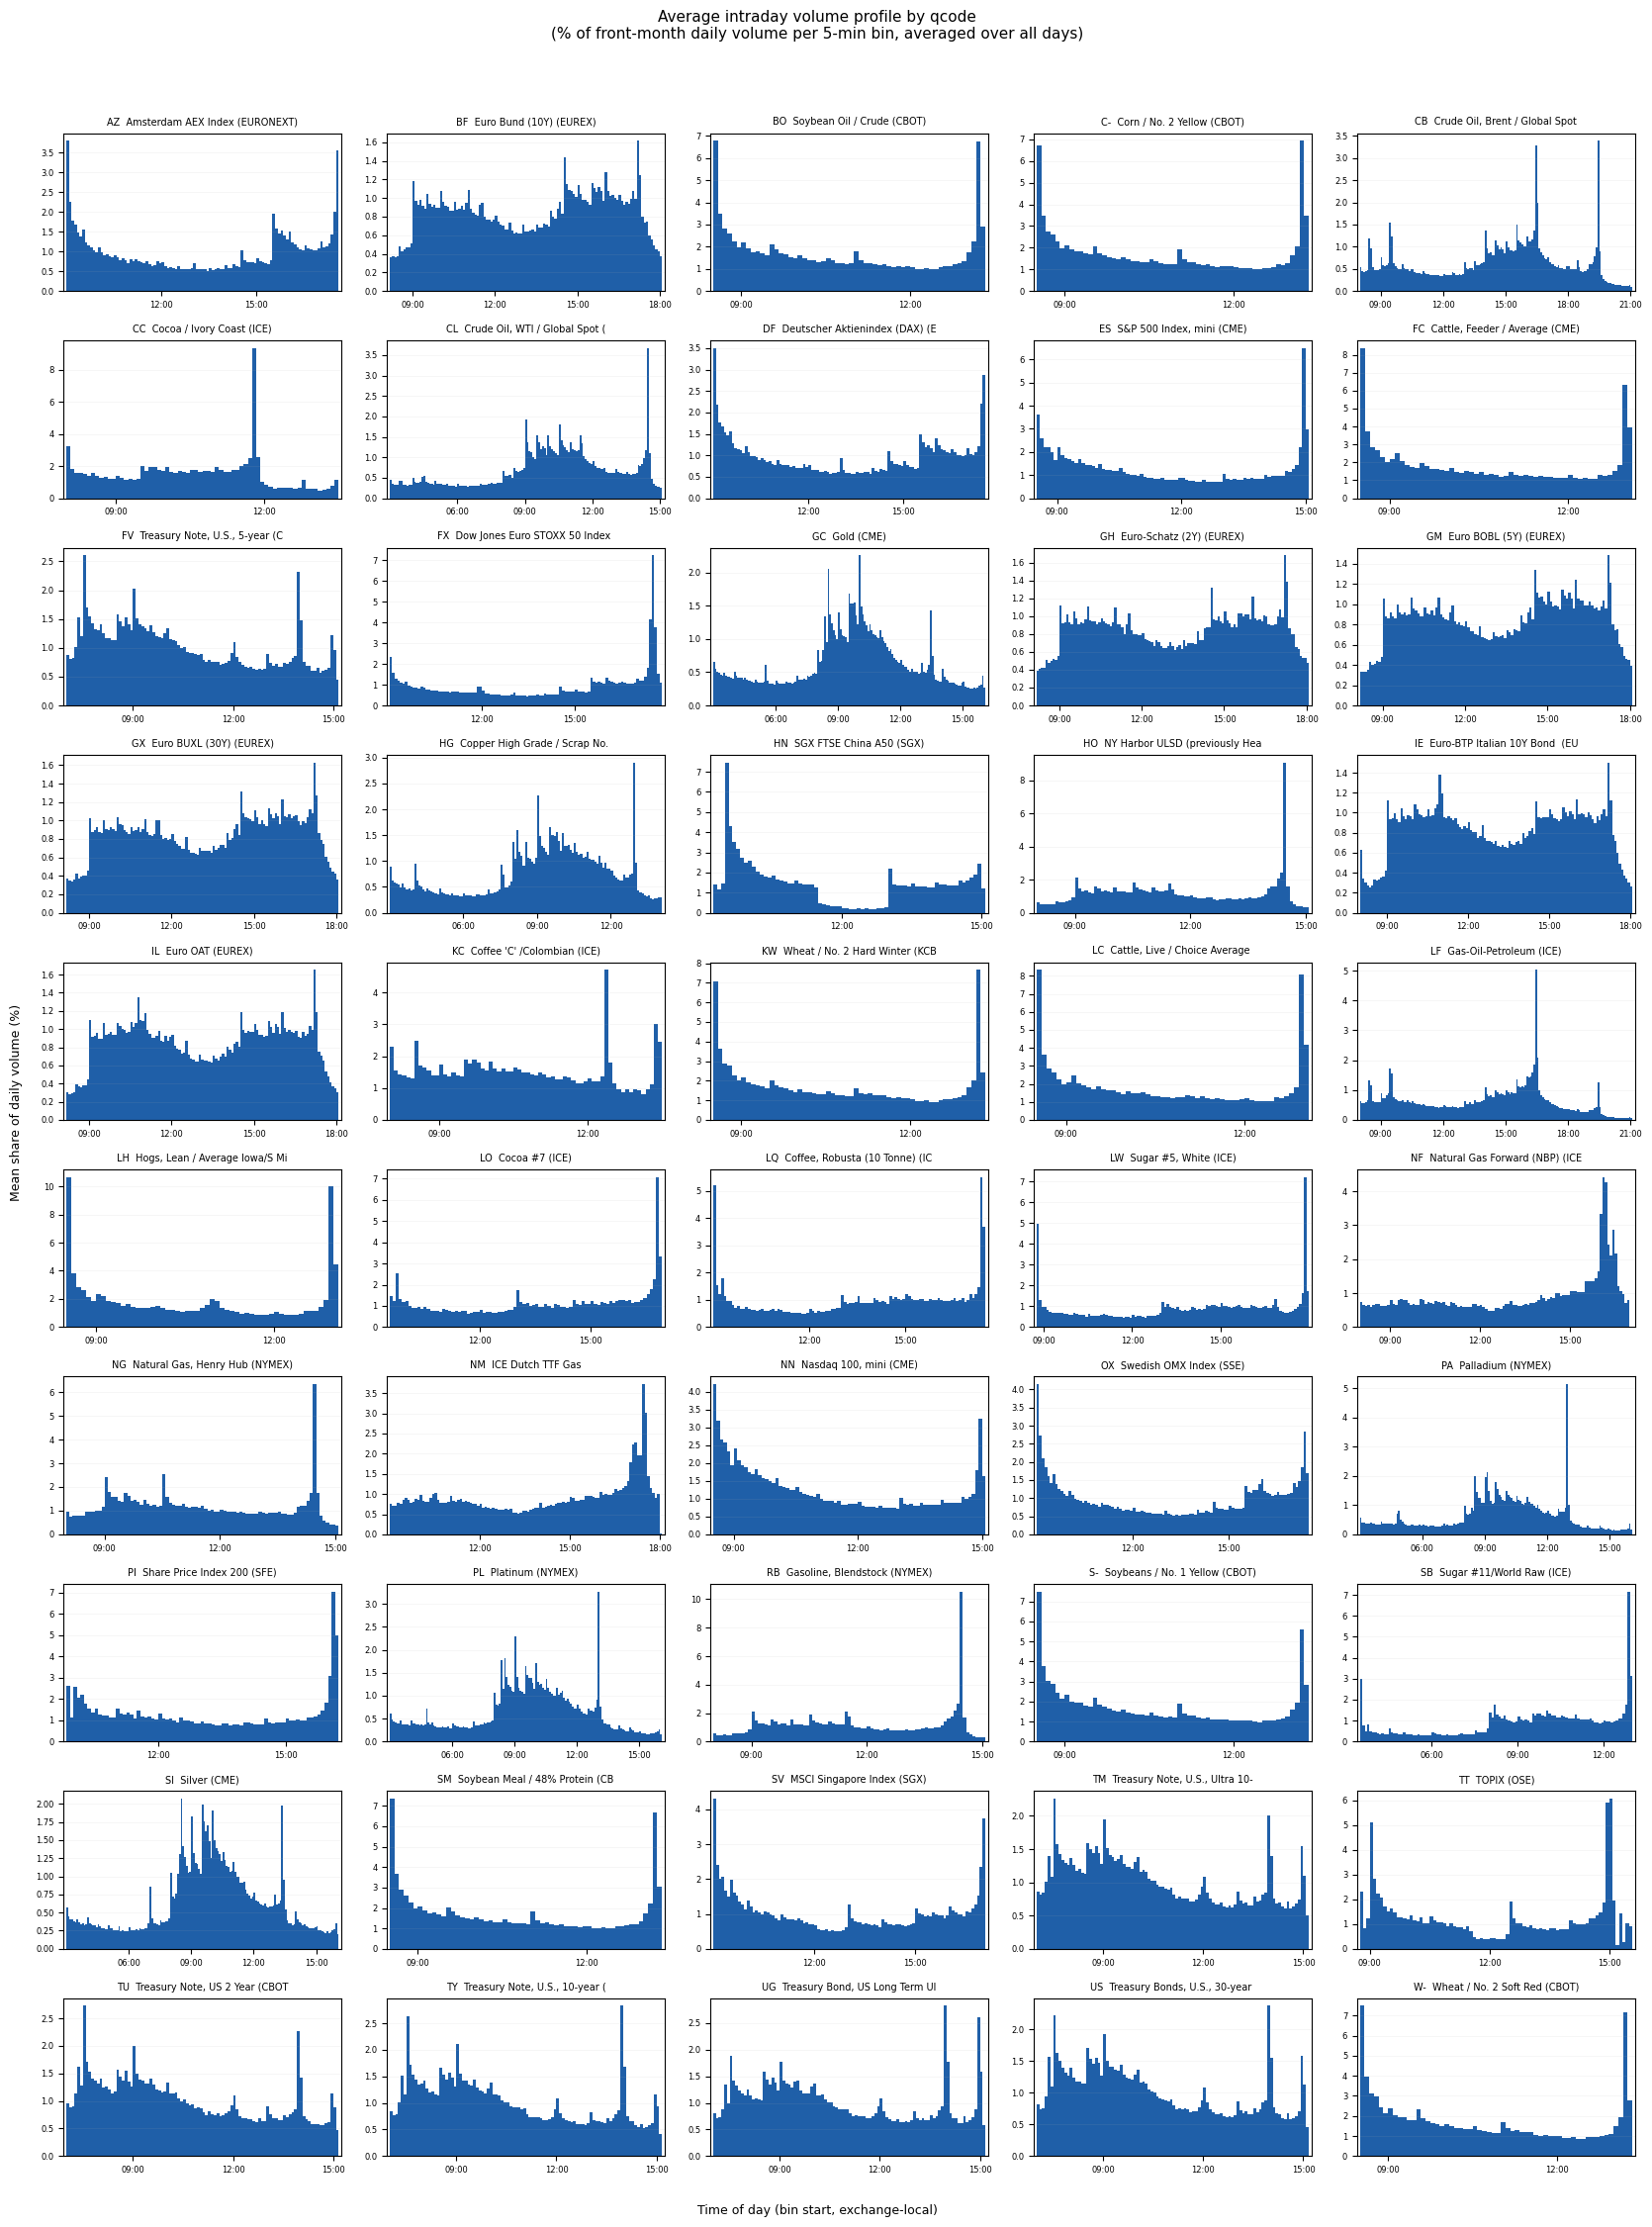

In [ ]:
# one panel per qcode: mean share of daily volume vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_proportion"] * 100
    ax.bar(x, y, width=5, align="edge", color="#1f5fa8", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday volume profile by qcode\n"
    "(% of front-month daily volume per 5-min bin, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean share of daily volume (%)", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()


---

## Average intraday volatility profile per qcode

The same construction as the volume profile, but for **volatility**. Each 5-minute bin's variance is estimated with the **Rogers–Satchell (RS)** estimator from the bin's OHLC:

$$\sigma_{RS}^2 = \underbrace{\ln\!\left(\frac{H}{C}\right)\ln\!\left(\frac{H}{O}\right)}_{\text{upward component}} + \underbrace{\ln\!\left(\frac{L}{C}\right)\ln\!\left(\frac{L}{O}\right)}_{\text{downward component}}$$

Both components are ≥ 0 (since `H ≥ O, C` and `L ≤ O, C`), so $\sigma_{RS}^2 \ge 0$. For each qcode we average the bin variance across all trading days — bin by bin — giving one intraday volatility profile per qcode in **absolute RS-variance units** (no normalisation; the curve does *not* sum to 1).

**Two outlier safeguards before averaging:**

1. **Bad-tick drop.** A handful of bins carry a corrupted OHLC price (a misplaced decimal makes one of O/H/L/C 10–100× off, or a stray near-zero print). Because RS uses logs of price ratios, one such bin produces a fake variance millions of times larger than a real bar. A 5-minute bar with a **high/low ratio above 2** (>100% range) is physically implausible here, so those bins are dropped as bad data and displayed below so the removal is auditable.
2. **Winsorisation.** Even after that, a few legitimate-but-extreme days can dominate a bin's mean. So within each **(qcode, time-of-day) slot** we **winsorise the cross-day RS variance to its central 95% (the 2.5–97.5 percentiles)** before averaging — clipping each slot against *its own* history, which tames day-specific spikes while preserving the genuine time-of-day shape (a high-variance bin isn't clipped down to a low-variance bin's level).

`BINNED_DATA` holds one security per `(qcode, date)` — the front-month — so no contract selection is needed. The result is one curve per qcode: *typical (winsorised) return variance realised in each 5-min bin*.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

# full table so the bad-tick rows below can show every field (signed volume,
# twa bid/ask, etc.)
binned = pl.read_csv("data/raw/binned_data.csv")

# per-bin Rogers-Satchell variance: ln(H/C)ln(H/O) + ln(L/C)ln(L/O)
rs_var = (
    (pl.col("high") / pl.col("close")).log() * (pl.col("high") / pl.col("open")).log()
    + (pl.col("low") / pl.col("close")).log() * (pl.col("low") / pl.col("open")).log()
)
price_cols = ["open", "high", "low", "close"]

# bins with all four prices present and positive (logs must be defined), plus
# the high/low ratio used to flag corrupted-OHLC bad ticks
bins_ok = (
    binned
    .filter(pl.all_horizontal([pl.col(c).is_not_null() & (pl.col(c) > 0) for c in price_cols]))
    .with_columns(
        rs_var.alias("rs_var"),
        (pl.col("high") / pl.col("low")).alias("hi_lo_ratio"),
    )
)

# (1) drop bad ticks: a 5-min bar with >100% high/low range is implausible here
MAX_HL_RATIO = 2.0
bad_bins = bins_ok.filter(pl.col("hi_lo_ratio") > MAX_HL_RATIO).sort("hi_lo_ratio", descending=True)
vol = bins_ok.filter(pl.col("hi_lo_ratio") <= MAX_HL_RATIO)
print(f"dropped {bad_bins.height} bad-tick bins (high/low > {MAX_HL_RATIO}) of {bins_ok.height:,}")

# (2) winsorise each (qcode, time-of-day) slot's cross-day RS variance to its
# central 95% (2.5-97.5 pct) before averaging, so a few extreme days can't
# dominate that bin's mean
WINSOR_LO, WINSOR_HI = 0.025, 0.975
slot = ["qcode", "bin_start_time"]
lo = pl.col("rs_var").quantile(WINSOR_LO).over(slot)
hi = pl.col("rs_var").quantile(WINSOR_HI).over(slot)
vol = vol.with_columns(pl.col("rs_var").clip(lo, hi).alias("rs_var_w"))

# average the winsorised bin variance across all trading days, bin by bin
# (no normalisation — absolute RS-variance units)
vol_profile = (
    vol
    .group_by(slot)
    .agg(pl.col("rs_var_w").mean().alias("mean_rs_var"))
    .with_columns(
        (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
         + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
    )
    .select("qcode", "bin_start_time", "minutes", "mean_rs_var")
    .sort("qcode", "minutes")
)
vol_profile.head()

dropped 39 bad-tick bins (high/low > 2.0) of 13,037,793


qcode,bin_start_time,minutes,mean_rs_var
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.000003
"""AZ""","""09:05:00.000000000""",545,0.000002
"""AZ""","""09:10:00.000000000""",550,0.000001
"""AZ""","""09:15:00.000000000""",555,0.000001
"""AZ""","""09:20:00.000000000""",560,8.9851e-7


In [ ]:
# the bad-tick bins removed above (corrupted OHLC), worst first — full record of
# every field. Note how one of O/H/L/C is 10-100x off the others (or a near-zero
# print), while volume / signed_volume / twa_bid / twa_ask look normal.
lead = [
    "qcode", "security", "publication_date", "bin_start_time",
    "open", "high", "low", "close", "hi_lo_ratio", "rs_var",
    "volume", "signed_volume", "trade_count", "vwap", "twa_bid", "twa_ask",
]
ordered = lead + [c for c in bad_bins.columns if c not in lead]
with pl.Config(tbl_rows=bad_bins.height, tbl_cols=-1):
    display(bad_bins.select(ordered))

qcode,security,publication_date,bin_start_time,open,high,low,close,hi_lo_ratio,rs_var,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,gmt_offset_hours,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,bid_start,bid_end,ask_start,ask_end
str,str,str,str,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64
"""RB""","""XB2016X Comdty""","""2016-10-26""","""14:00:00.000000000""",1.4757,1.4778,0.0001,1.4778,14778.0,92.163529,37,-31,9,0.35927,1.476068,1.476521,-4.0,1.966753,1.749577,1,3,2,4,1.4756,1.4773,1.4759,1.4778
"""RB""","""XB2016Q Comdty""","""2016-07-28""","""14:00:00.000000000""",0.0001,1.306,0.0001,1.306,13060.0,0.0,51,-43,7,0.153694,1.305871,1.306541,-4.0,1.39337,1.7455,1,3,1,2,1.3069,1.3055,1.3078,1.3064
"""OX""","""QC2017Z Index""","""2017-11-23""","""13:15:00.000000000""",1615.25,1615.5,13.15,1615.0,122.851711,23.143276,215,-142,48,1391.672093,1615.073783,1615.354933,1.0,42.832453,41.32209,57,29,43,38,1615.25,1615.0,1615.5,1615.25
"""OX""","""QC2017Z Index""","""2017-11-23""","""13:30:00.000000000""",1615.5,1615.5,13.15,1615.25,122.851711,23.144765,234,-6,43,1409.625,1615.002507,1615.262985,1.0,32.300747,32.421657,7,37,49,50,1615.5,1615.25,1615.75,1615.5
"""OX""","""QC2018V Index""","""2018-10-03""","""15:15:00.000000000""",1671.0,167275.0,1669.75,1670.0,100.179668,21.219992,7008,5906,197,96194.258169,1670.434397,1670.702906,2.0,30.39804,49.808447,36,13,56,58,1671.0,1669.75,1671.25,1670.0
"""OX""","""QC2019M Index""","""2019-06-11""","""16:00:00.000000000""",1595.0,1596.25,15.95,1596.0,100.07837,21.210479,1317,-205,181,1055.839787,1595.630117,1595.886064,2.0,37.421623,47.01414,46,19,26,54,1594.75,1595.75,1595.0,1596.0
"""OX""","""QC2024G Index""","""2024-01-30""","""15:25:00.000000000""",2370.5,2371.0,24.5,2369.5,96.77551,20.902929,606,47,394,2334.97401,2369.64541,2369.896968,1.0,23.911633,21.156893,29,30,8,8,2370.25,2369.25,2370.5,2369.5
"""CL""","""CL2020K Comdty""","""2020-04-20""","""13:55:00.000000000""",0.82,0.86,0.01,0.69,86.0,18.669008,1540,-456,741,0.293234,0.318789,0.3700003,-4.0,3.225063,2.632743,2,1,3,4,0.84,0.6,0.93,0.7
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:00:00.000000000""",0.61,0.7,0.03,0.37,23.333333,7.655466,794,-262,391,0.271058,0.322584,0.3680749,-4.0,2.549037,2.692943,1,1,4,1,0.6,0.37,0.7,0.4


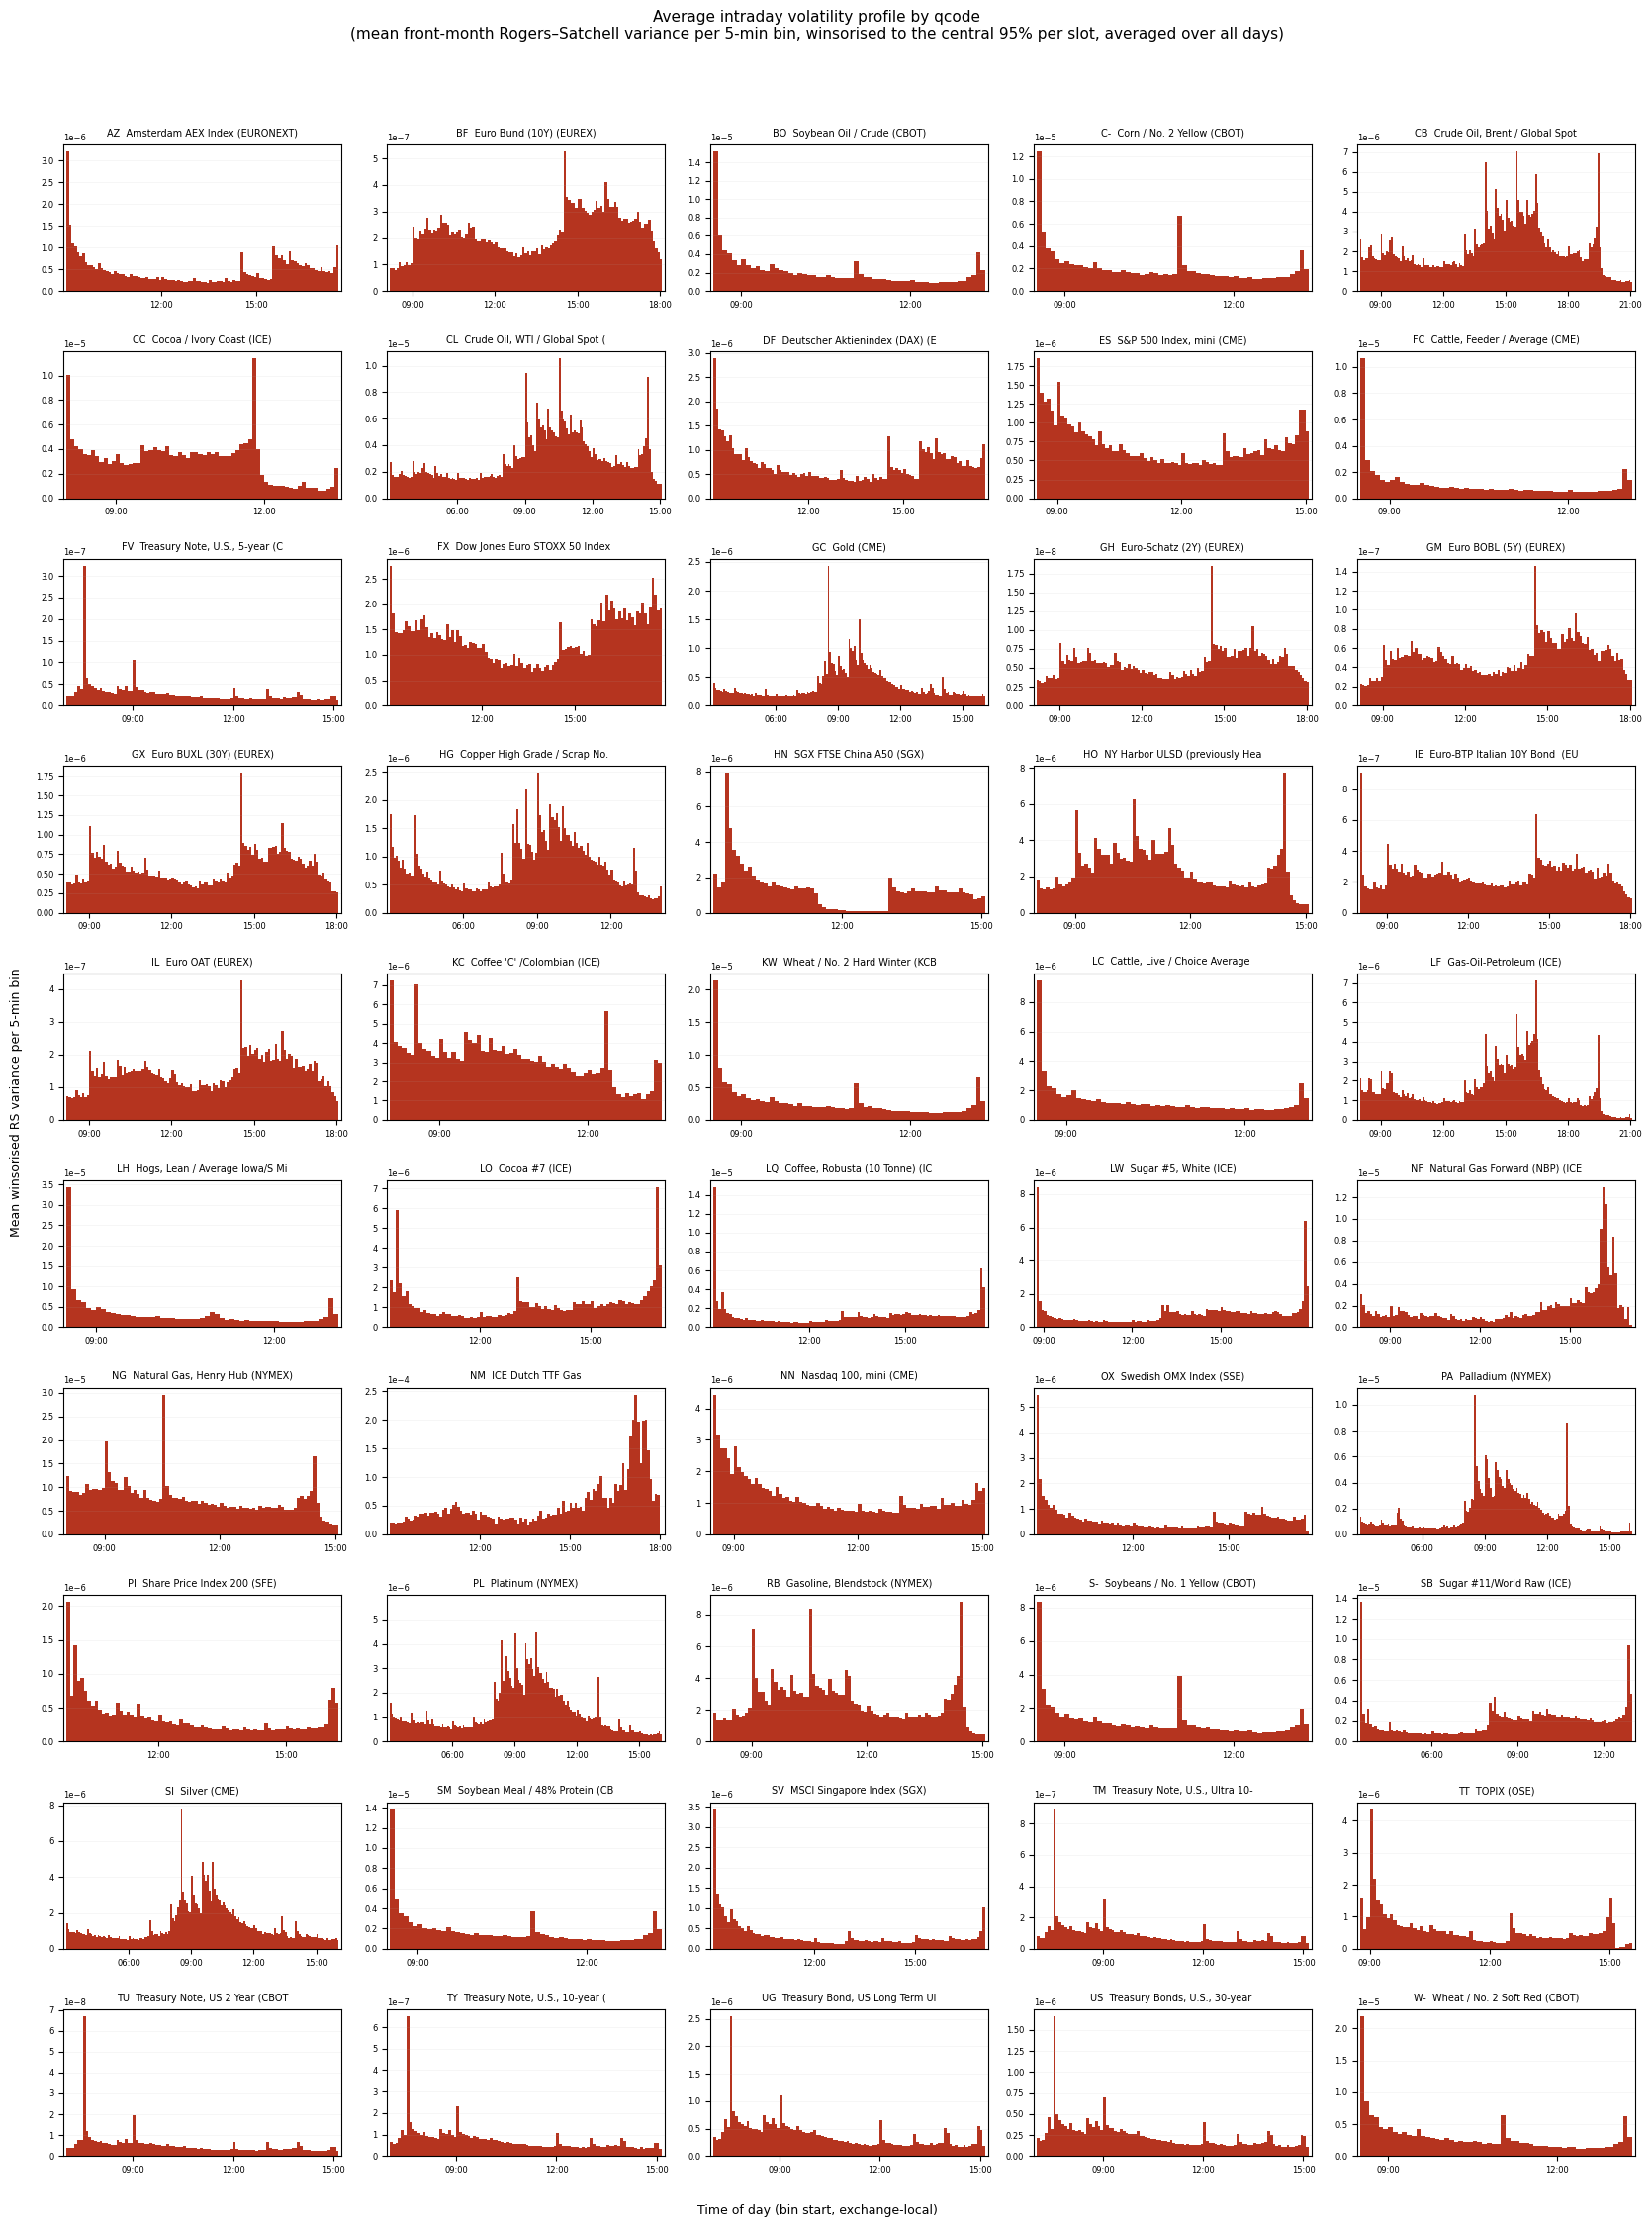

In [ ]:
# one panel per qcode: mean (winsorised) RS variance vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = vol_profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = vol_profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_rs_var"]
    ax.bar(x, y, width=5, align="edge", color="#b5341f", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday volatility profile by qcode\n"
    "(mean front-month Rogers–Satchell variance per 5-min bin, winsorised to the "
    "central 95% per slot, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean winsorised RS variance per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()

---

## Average intraday spread profile per qcode

Same construction once more, now for the **quoted spread** — `twa_ask - twa_bid` per 5-minute bin (the time-weighted average ask minus bid). This is exactly the spread `execution.py` charges in its fill model (`fill_price = vwap ± x · spread`), so its intraday shape is what drives execution friction through the day.

For each qcode we average the per-bin spread across all trading days, bin by bin, in the instrument's **own price units** (panels autoscale). Same winsorisation as the volatility profile: within each **(qcode, time-of-day) slot** the cross-day spread is clipped to its central 95% (2.5–97.5 pct) before averaging, so occasional quote blow-outs don't dominate a bin's mean.

No high/low bad-tick filter is needed here — the spread comes from the bid/ask snapshots, which stayed clean even in the corrupted-OHLC bins (those bad ticks lived in `high`/`low`/`vwap`, not the quotes).

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

spr = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "twa_bid", "twa_ask"
)
spr = (
    spr.filter(pl.col("twa_bid").is_not_null() & pl.col("twa_ask").is_not_null())
       .with_columns((pl.col("twa_ask") - pl.col("twa_bid")).alias("spread"))
       .filter(pl.col("spread") >= 0)          # drop any crossed-quote bins
)

# winsorise each (qcode, time-of-day) slot's cross-day spread to its central 95%
WINSOR_LO, WINSOR_HI = 0.025, 0.975
slot = ["qcode", "bin_start_time"]
lo = pl.col("spread").quantile(WINSOR_LO).over(slot)
hi = pl.col("spread").quantile(WINSOR_HI).over(slot)
spr = spr.with_columns(pl.col("spread").clip(lo, hi).alias("spread_w"))

# average the winsorised spread across all trading days, bin by bin (price units)
spread_profile = (
    spr.group_by(slot)
       .agg(pl.col("spread_w").mean().alias("mean_spread"))
       .with_columns(
           (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
            + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
       )
       .select("qcode", "bin_start_time", "minutes", "mean_spread")
       .sort("qcode", "minutes")
)
spread_profile.head()

qcode,bin_start_time,minutes,mean_spread
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.135002
"""AZ""","""09:05:00.000000000""",545,0.109569
"""AZ""","""09:10:00.000000000""",550,0.102748
"""AZ""","""09:15:00.000000000""",555,0.099345
"""AZ""","""09:20:00.000000000""",560,0.096216


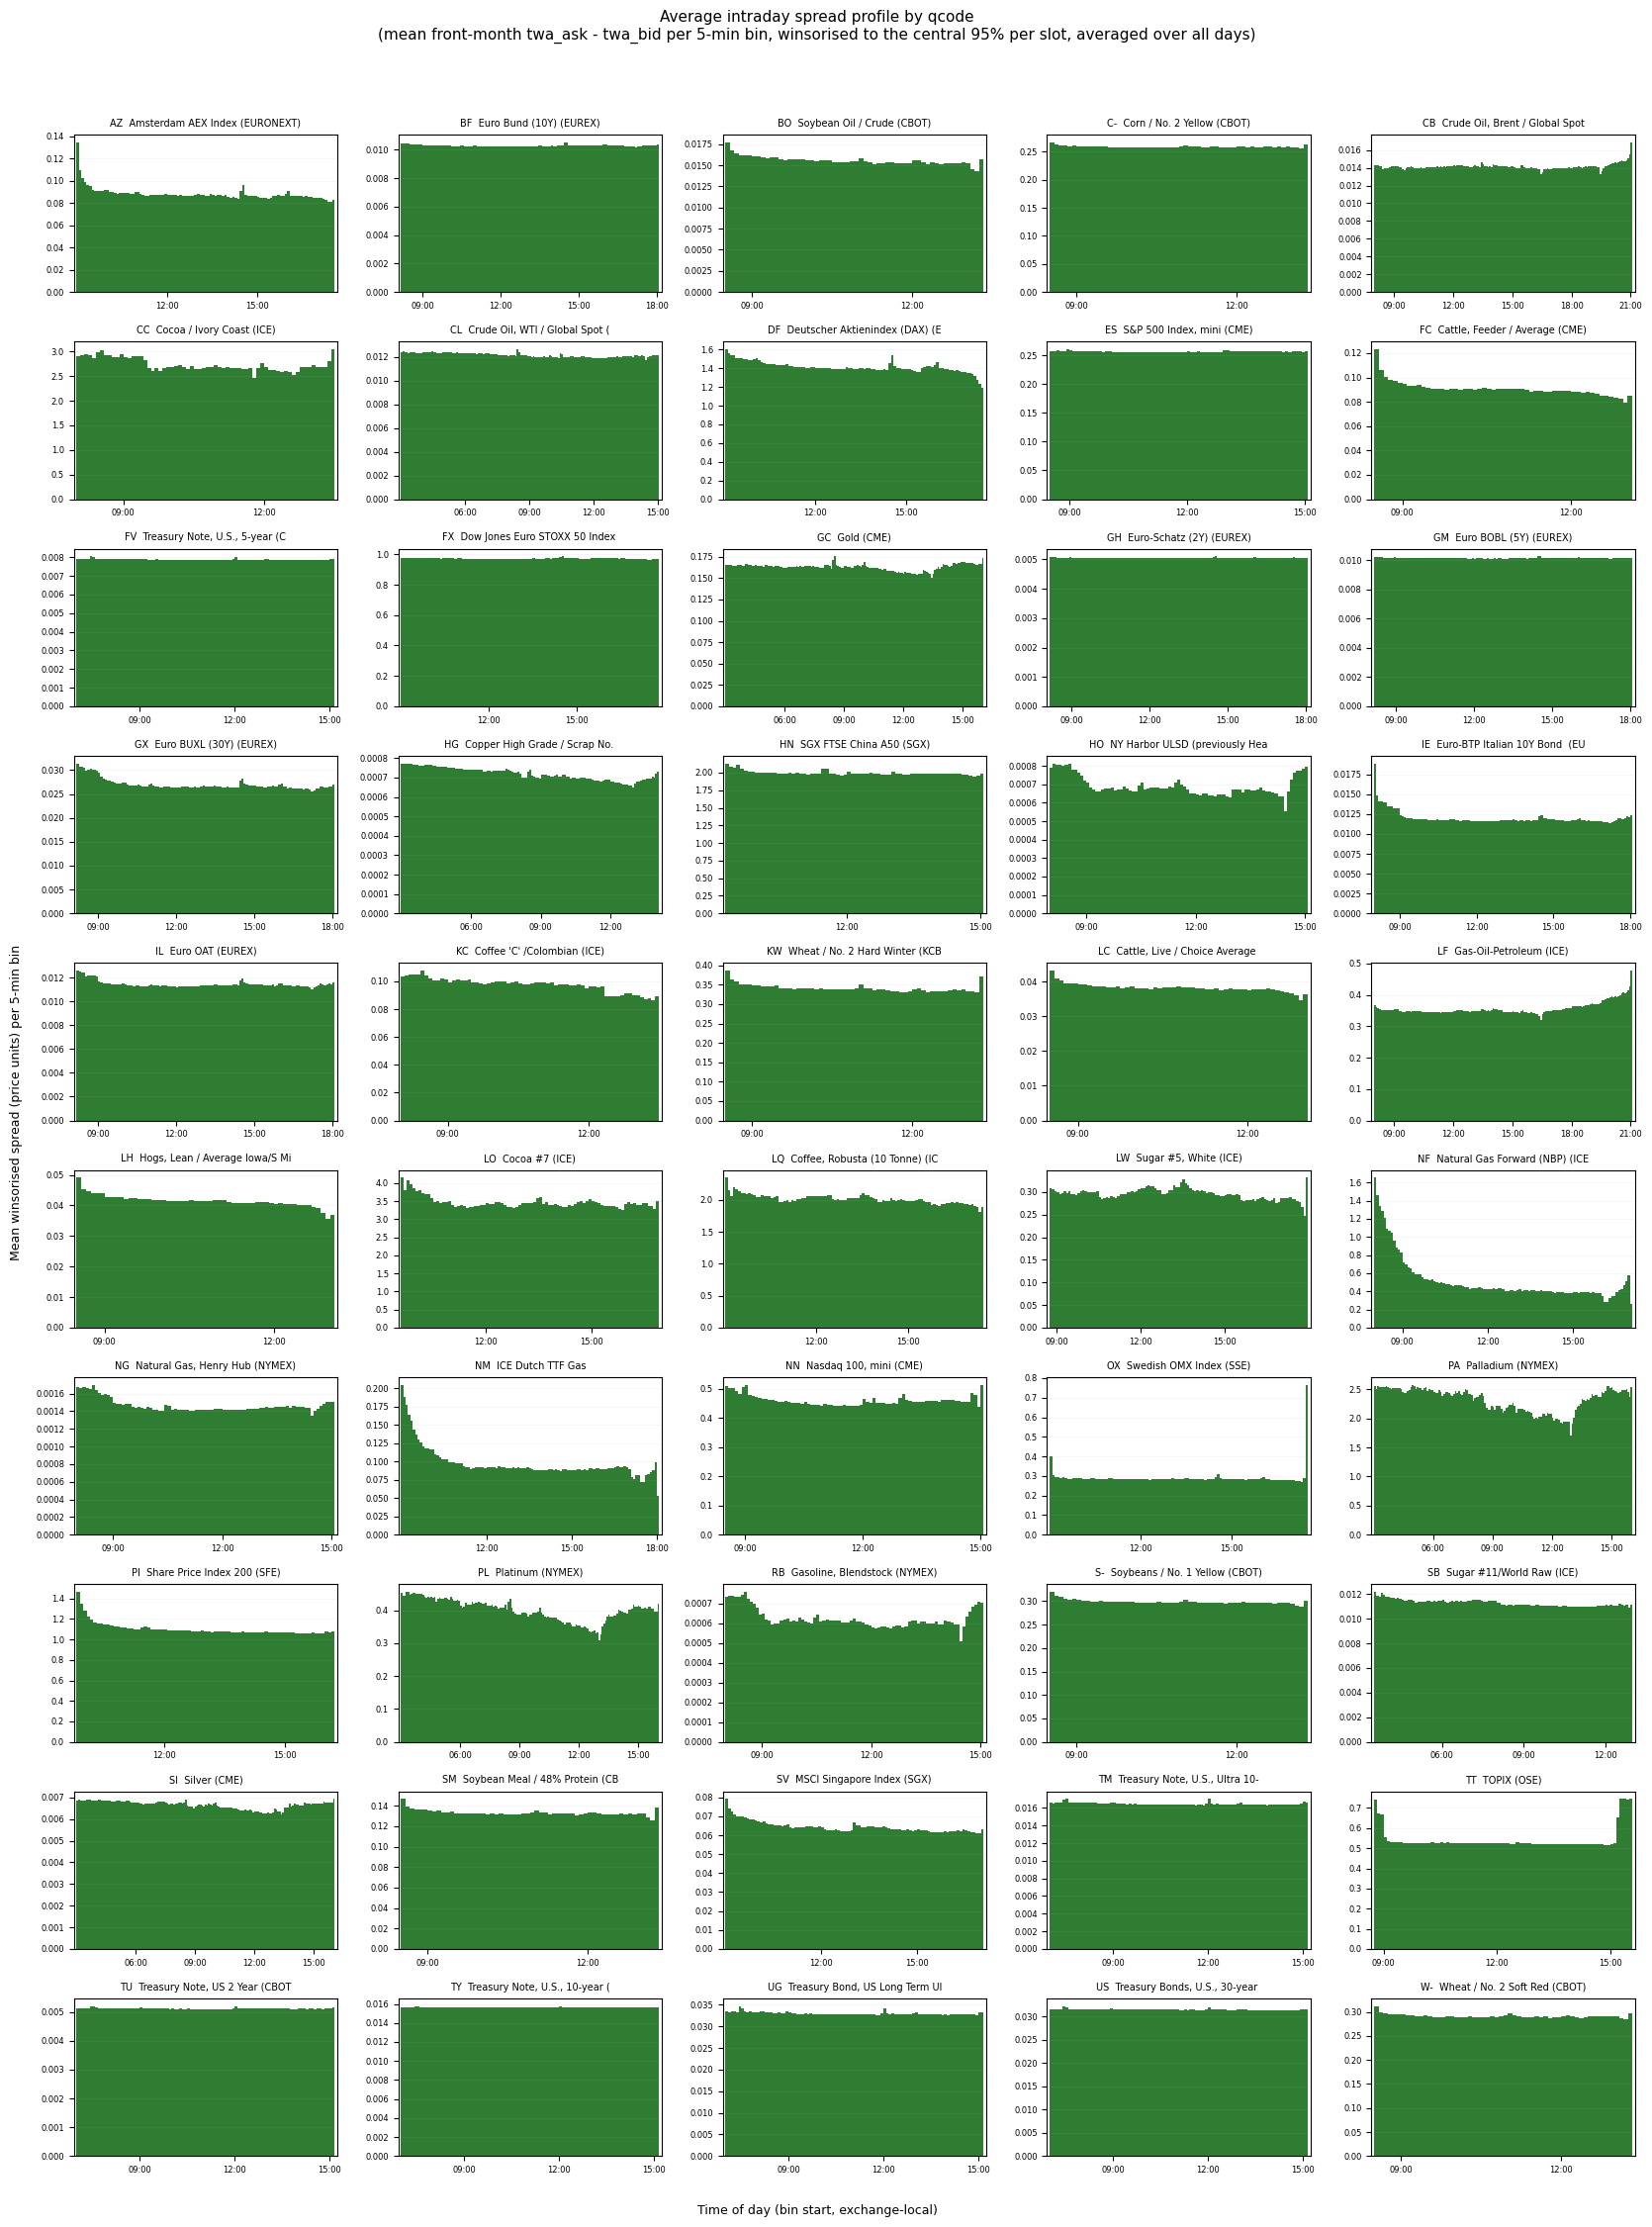

In [ ]:
# one panel per qcode: mean (winsorised) quoted spread vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = spread_profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = spread_profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_spread"]
    ax.bar(x, y, width=5, align="edge", color="#2e7d32", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday spread profile by qcode\n"
    "(mean front-month twa_ask - twa_bid per 5-min bin, winsorised to the "
    "central 95% per slot, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean winsorised spread (price units) per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()

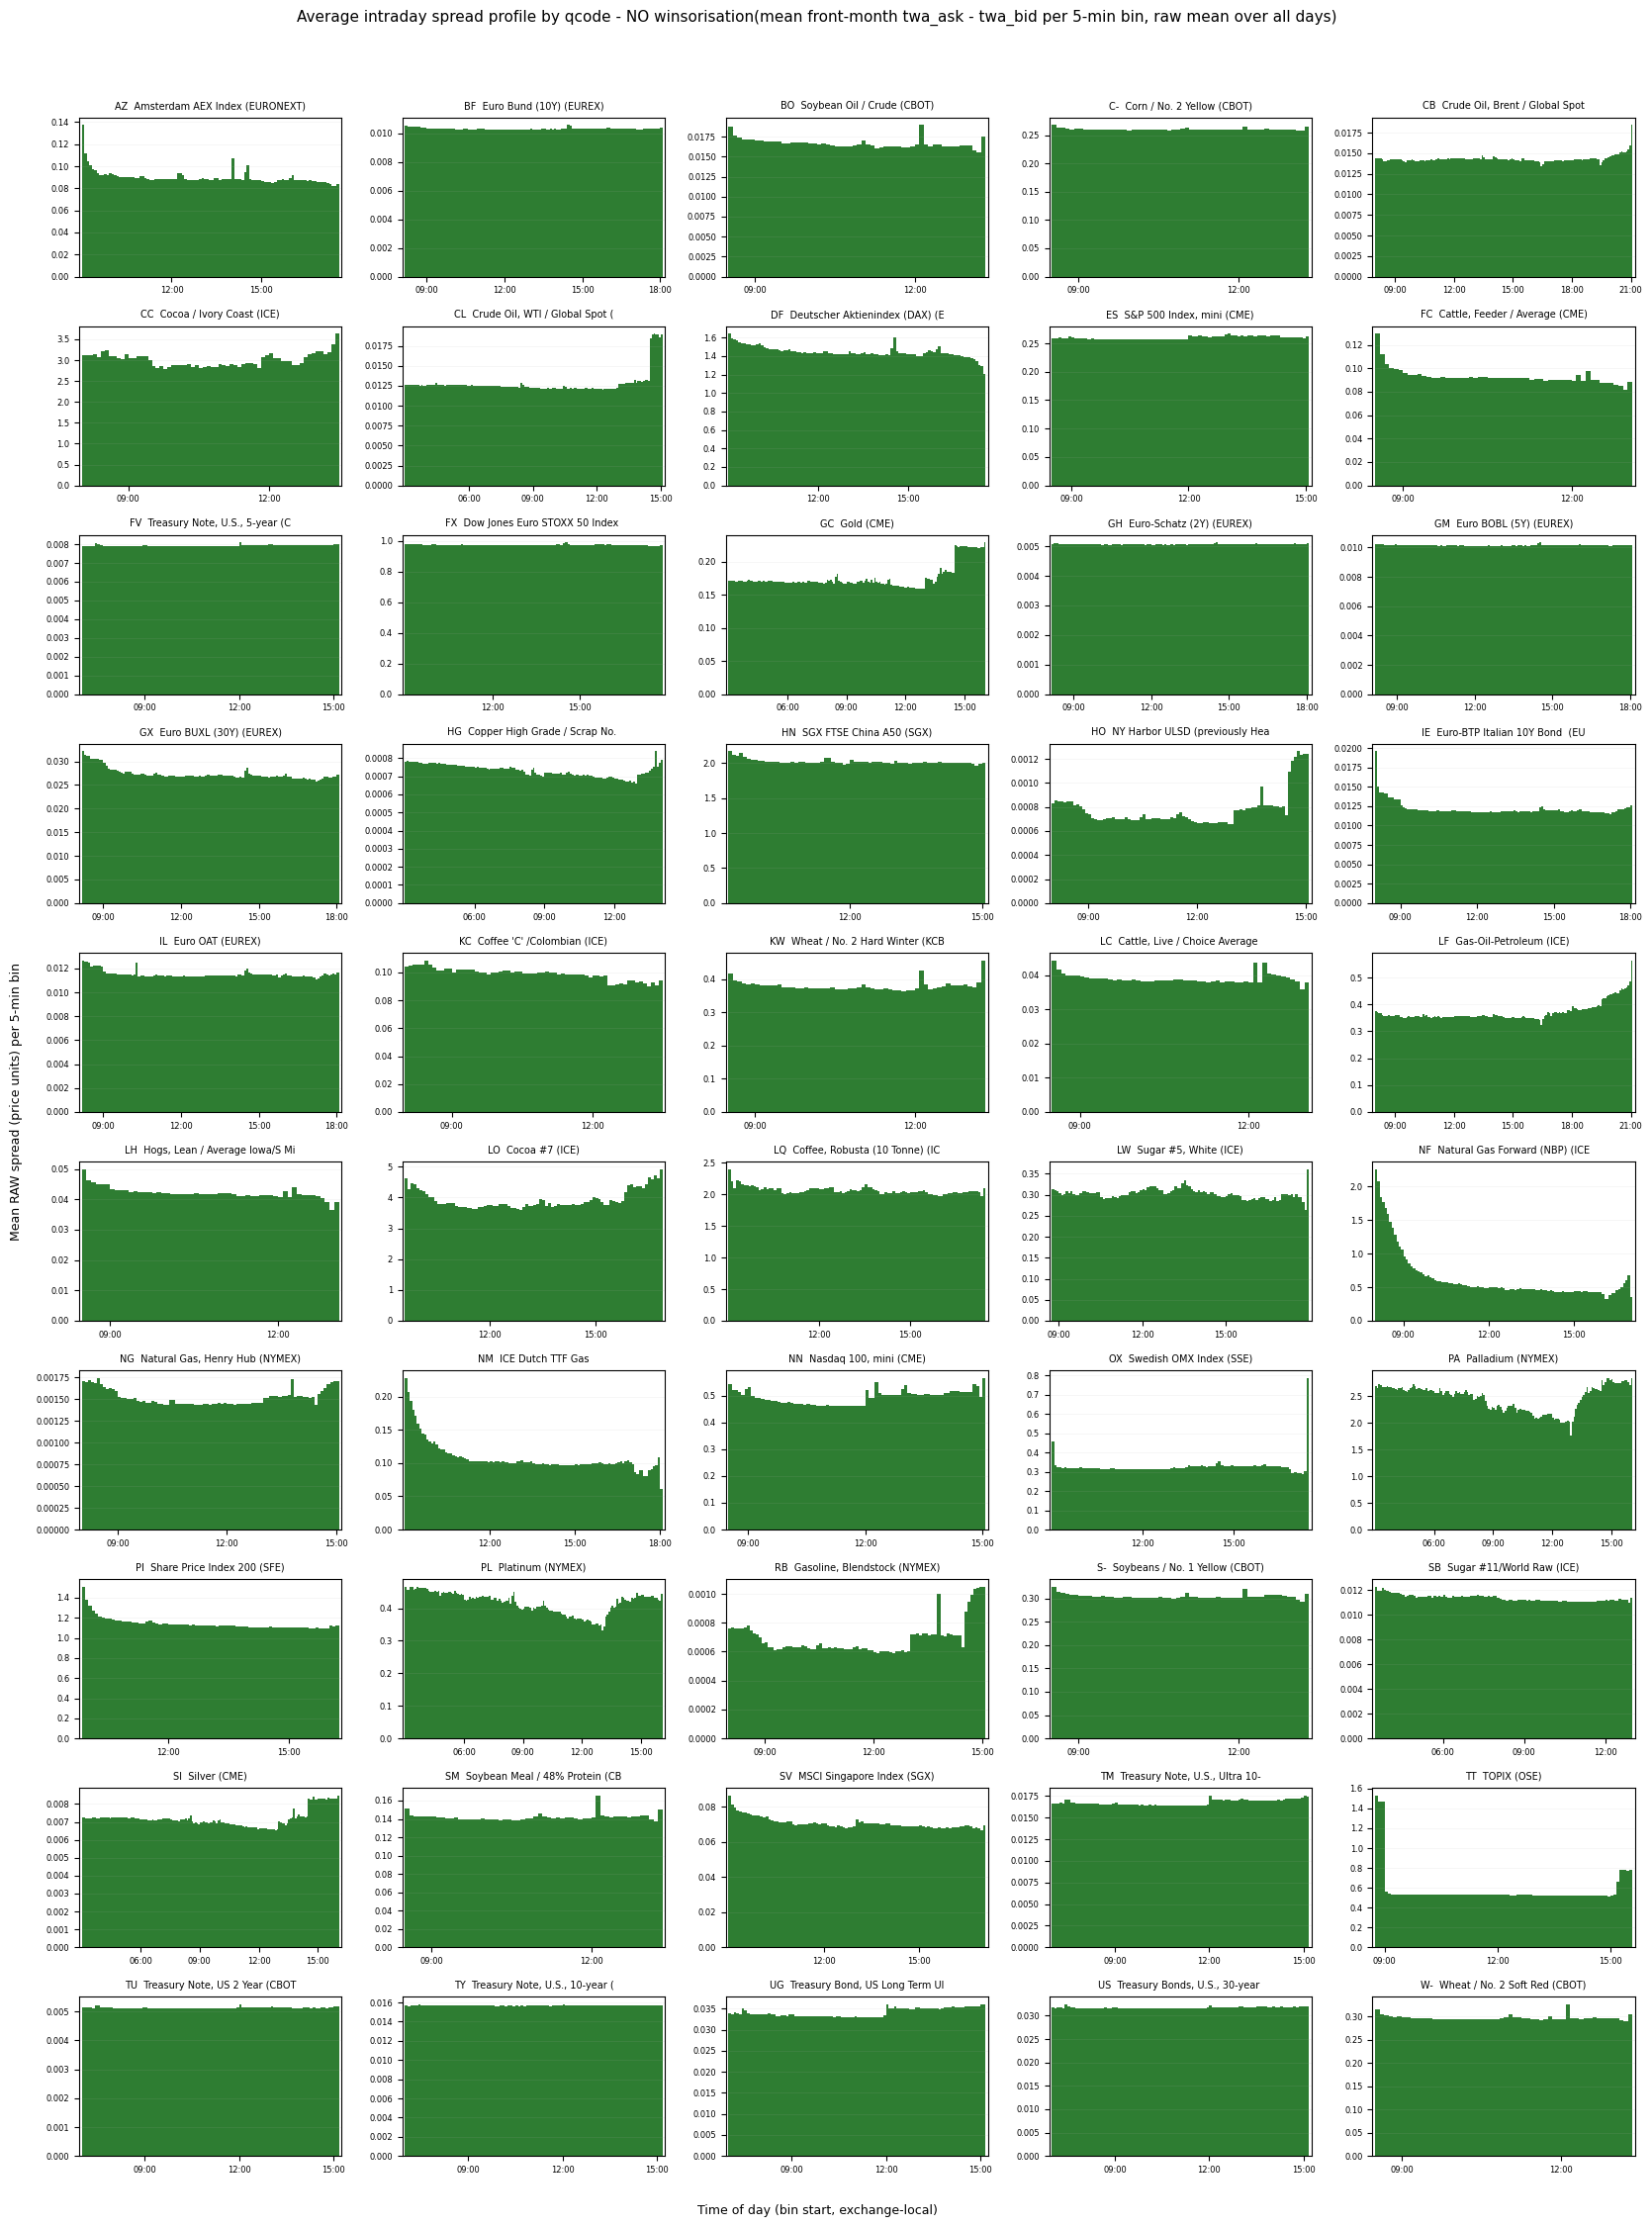

In [ ]:
# one panel per qcode: mean RAW (un-winsorised) quoted spread vs time of day
# same as the cell above, but WITHOUT the central-95% winsorisation step
spr_raw = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "twa_bid", "twa_ask"
)
spr_raw = (
    spr_raw.filter(pl.col("twa_bid").is_not_null() & pl.col("twa_ask").is_not_null())
           .with_columns((pl.col("twa_ask") - pl.col("twa_bid")).alias("spread"))
           .filter(pl.col("spread") >= 0)          # drop any crossed-quote bins
)

# average the RAW spread across all trading days, bin by bin (no winsorisation)
spread_profile_raw = (
    spr_raw.group_by(["qcode", "bin_start_time"])
           .agg(pl.col("spread").mean().alias("mean_spread"))
           .with_columns(
               (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
                + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
           )
           .select("qcode", "bin_start_time", "minutes", "mean_spread")
           .sort("qcode", "minutes")
)

qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = spread_profile_raw["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = spread_profile_raw.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_spread"]
    ax.bar(x, y, width=5, align="edge", color="#2e7d32", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday spread profile by qcode - NO winsorisation"
    "(mean front-month twa_ask - twa_bid per 5-min bin, raw mean over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean RAW spread (price units) per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()

## Sanity check: binned data integrity

Flags rows that violate internal consistency. **Hard** checks (OHLC ordering, crossed quotes, negative volume, etc.) should all be 0. **Soft** checks are informational — they catch values that are unusual but can be legitimate:
- *non-positive price* rows are real for `CL` on 2020-04-20 (the negative-WTI event) but look like bad ticks for `NM` (TTF gas zeros).
- *vwap outside [twa_bid, twa_ask]* is **expected** and not an error: `vwap` is trade-volume-weighted while `twa_bid/twa_ask` are time-weighted quotes, so trades can print outside the time-averaged band.

In [ ]:
# ----------------------------------------------------------------------
# Sanity check on the raw binned data. Hard checks should all read 0.
# ----------------------------------------------------------------------
import polars as pl

raw = pl.read_csv("data/raw/binned_data.csv")
N = raw.height
eps = 1e-9

# (label, expression, kind)  -- kind "hard" must be 0; "soft" is informational
checks = [
    # --- OHLC internal consistency ---
    ("high < low",                      pl.col("high") < pl.col("low"),                                                  "hard"),
    ("open outside [low, high]",        (pl.col("open")  > pl.col("high")+eps) | (pl.col("open")  < pl.col("low")-eps), "hard"),
    ("close outside [low, high]",       (pl.col("close") > pl.col("high")+eps) | (pl.col("close") < pl.col("low")-eps), "hard"),
    ("vwap > high (vol>0)",             (pl.col("volume")>0) & (pl.col("vwap") > pl.col("high")+eps),                    "hard"),
    ("vwap < low  (vol>0)",             (pl.col("volume")>0) & (pl.col("vwap") < pl.col("low")-eps),                     "hard"),
    # --- quote consistency (no crossed quotes) ---
    ("twa_bid > twa_ask (crossed)",     pl.col("twa_bid")   > pl.col("twa_ask")+eps,                                     "hard"),
    ("bid_start > ask_start (crossed)", pl.col("bid_start") > pl.col("ask_start")+eps,                                   "hard"),
    ("bid_end > ask_end (crossed)",     pl.col("bid_end")   > pl.col("ask_end")+eps,                                     "hard"),
    # --- volume / trade-count consistency ---
    ("volume < 0",                      pl.col("volume") < 0,                                                            "hard"),
    ("trade_count < 0",                 pl.col("trade_count") < 0,                                                       "hard"),
    ("|signed_volume| > volume",        pl.col("signed_volume").abs() > pl.col("volume")+eps,                           "hard"),
    ("vol>0 but trade_count==0",        (pl.col("volume")>0) & (pl.col("trade_count")==0),                              "hard"),
    ("vol==0 but trade_count>0",        (pl.col("volume")==0) & (pl.col("trade_count")>0),                              "hard"),
    ("vwap null while vol>0",           (pl.col("volume")>0) & pl.col("vwap").is_null(),                                "hard"),
    ("negative quote size",             (pl.col("bid_size_start")<0) | (pl.col("ask_size_start")<0)
                                        | (pl.col("bid_size_end")<0) | (pl.col("ask_size_end")<0),                      "hard"),
    # --- price sign: CL/TTF can legitimately be <= 0, so SOFT ---
    ("non-positive high or low",        (pl.col("high")<=0) | (pl.col("low")<=0),                                       "soft"),
    ("non-positive vwap (vol>0)",       (pl.col("volume")>0) & (pl.col("vwap")<=0),                                     "soft"),
    # --- vwap vs time-weighted quote band: EXPECTED to be non-zero, so SOFT ---
    ("vwap outside [twa_bid, twa_ask]", (pl.col("volume")>0) & ((pl.col("vwap")>pl.col("twa_ask")+eps)
                                                               | (pl.col("vwap")<pl.col("twa_bid")-eps)),               "soft"),
]

summary = pl.DataFrame({
    "check":  [c[0] for c in checks],
    "kind":   [c[2] for c in checks],
    "n_rows": [raw.filter(c[1].fill_null(False)).height for c in checks],
}).with_columns((pl.col("n_rows") / N * 100).round(3).alias("pct"))

print(f"binned_data.csv: {N:,} rows")
with pl.Config(tbl_rows=-1, fmt_str_lengths=60):
    print(summary)

hard_fail = summary.filter((pl.col("kind") == "hard") & (pl.col("n_rows") > 0))
print(f"HARD-check failures: {hard_fail.height}  (0 = all integrity checks pass)")

# Pull the actual flagged non-positive-price rows for eyeballing
price_flag = raw.filter(
    ((pl.col("high") <= 0) | (pl.col("low") <= 0)
     | ((pl.col("volume") > 0) & (pl.col("vwap") <= 0))).fill_null(False)
).select(["qcode", "security", "publication_date", "bin_start_time",
          "open", "high", "low", "close", "vwap", "volume"]).sort(["qcode", "publication_date"])

print(f"Non-positive-price rows flagged: {price_flag.height}  "f"(qcodes: {price_flag['qcode'].unique().sort().to_list()})")
price_flag

binned_data.csv: 13,051,428 rows
shape: (18, 4)
┌─────────────────────────────────┬──────┬─────────┬────────┐
│ check                           ┆ kind ┆ n_rows  ┆ pct    │
│ ---                             ┆ ---  ┆ ---     ┆ ---    │
│ str                             ┆ str  ┆ i64     ┆ f64    │
╞═════════════════════════════════╪══════╪═════════╪════════╡
│ high < low                      ┆ hard ┆ 0       ┆ 0.0    │
│ open outside [low, high]        ┆ hard ┆ 0       ┆ 0.0    │
│ close outside [low, high]       ┆ hard ┆ 0       ┆ 0.0    │
│ vwap > high (vol>0)             ┆ hard ┆ 0       ┆ 0.0    │
│ vwap < low  (vol>0)             ┆ hard ┆ 0       ┆ 0.0    │
│ twa_bid > twa_ask (crossed)     ┆ hard ┆ 0       ┆ 0.0    │
│ bid_start > ask_start (crossed) ┆ hard ┆ 0       ┆ 0.0    │
│ bid_end > ask_end (crossed)     ┆ hard ┆ 0       ┆ 0.0    │
│ volume < 0                      ┆ hard ┆ 0       ┆ 0.0    │
│ trade_count < 0                 ┆ hard ┆ 0       ┆ 0.0    │
│ |signed_volume| > vo

qcode,security,publication_date,bin_start_time,open,high,low,close,vwap,volume
str,str,str,str,f64,f64,f64,f64,f64,i64
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:50:00.000000000""",-16.85,-16.85,-18.2,-18.2,-17.41339,59
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:40:00.000000000""",-24.48,-20.31,-25.0,-20.31,-22.460508,118
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:20:00.000000000""",-8.74,-8.74,-14.39,-13.98,-10.190288,555
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:45:00.000000000""",-20.0,-15.5,-21.07,-17.0,-18.102298,605
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:25:00.000000000""",-18.05,-18.05,-40.32,-37.11,-34.11742,748
…,…,…,…,…,…,…,…,…,…
"""NM""","""TZT2018F Comdty""","""2017-12-06""","""13:00:00.000000000""",0.0,20.775,0.0,20.775,1.2465,1000
"""NM""","""TZT2018F Comdty""","""2017-12-07""","""10:00:00.000000000""",0.0,0.0,0.0,0.0,0.0,70
"""NM""","""TZT2018F Comdty""","""2017-12-14""","""13:35:00.000000000""",0.0,20.175,0.0,20.175,8.646429,35


## Trading holidays hiding in the trade list

Some `(security, date)` rows in `trade_list.csv` fall on dates when the **whole exchange was shut** — the binned data still has rows for them, but every security on that exchange printed **zero** volume, so they are untradeable. These would otherwise distort fill-rate / shortfall stats and should be excluded from the backtest.

Detected as: exchange-wide total volume == 0 on a date the exchange otherwise trades. Recurring ones are Australian (ASX/SFE) **Australia Day (Jan 26)** and **ANZAC Day (Apr 25)**; also Singapore Labour Day, Swedish Midsummer Eve, European Labour Day, and the 2022 Queen Elizabeth II day of mourning. Note: `2016-07-14` (TOPIX/OSE) is not a Japanese holiday and looks more like a **data gap** than a true closure.

In [ ]:
# --- Flag trade-list dates that fall on an exchange-wide trading holiday ---
qm = pl.read_csv("data/raw/qcode_mapping.csv")
exch_of = dict(zip(qm["qcode"], qm["exchange"]))
desc_of = dict(zip(qm["qcode"], qm["description"]))

# total traded volume per (exchange, date) across all securities on that exchange
bd = pl.read_csv("data/raw/binned_data.csv", columns=["qcode", "publication_date", "volume"])
ex_vol = (
    bd.with_columns(pl.col("qcode").replace_strict(exch_of, default="?").alias("exch"))
      .group_by(["exch", "publication_date"])
      .agg(pl.col("volume").sum().alias("exch_vol"))
      .rename({"publication_date": "date"})
)
# an exchange-wide holiday = a date the exchange printed ZERO volume market-wide
holidays = ex_vol.filter(pl.col("exch_vol") == 0).select("exch", "date")

# which trade-list (security, date) rows land on such a day
tl = pl.read_csv("data/raw/trade_list.csv")
sm = pl.read_csv("data/raw/security_meta.csv").select("security", "qcode")
tl = (tl.join(sm, on="security", how="left")
        .with_columns(pl.col("qcode").replace_strict(exch_of, default="?").alias("exch")))

flagged = tl.join(holidays, on=["exch", "date"], how="inner").with_columns(
    pl.col("date").str.to_date().dt.strftime("%a").alias("dow"),
    pl.col("qcode").replace_strict(desc_of, default="").alias("instrument"),
)

print(f"trade-list rows on exchange-wide holidays: {flagged.height}")

holiday_dates = (flagged.select("date", "dow", "exch", "qcode", "instrument")
                        .unique().sort("date"))
with pl.Config(tbl_rows=-1, fmt_str_lengths=40):
    print(holiday_dates)

# `flagged` holds every untradeable trade-list row (with order_id columns intact) for exclusion downstream
flagged

trade-list rows on exchange-wide holidays: 108
shape: (18, 5)
┌────────────┬─────┬──────┬───────┬─────────────────────────────┐
│ date       ┆ dow ┆ exch ┆ qcode ┆ instrument                  │
│ ---        ┆ --- ┆ ---  ┆ ---   ┆ ---                         │
│ str        ┆ str ┆ str  ┆ str   ┆ str                         │
╞════════════╪═════╪══════╪═══════╪═════════════════════════════╡
│ 2016-01-26 ┆ Tue ┆ SFE  ┆ PI    ┆ Share Price Index 200 (SFE) │
│ 2016-04-25 ┆ Mon ┆ SFE  ┆ PI    ┆ Share Price Index 200 (SFE) │
│ 2016-05-02 ┆ Mon ┆ SGX  ┆ SV    ┆ MSCI Singapore Index (SGX)  │
│ 2016-07-14 ┆ Thu ┆ OSE  ┆ TT    ┆ TOPIX (OSE)                 │
│ 2017-01-26 ┆ Thu ┆ SFE  ┆ PI    ┆ Share Price Index 200 (SFE) │
│ 2017-05-01 ┆ Mon ┆ EDX  ┆ NM    ┆ ICE Dutch TTF Gas           │
│ 2018-01-26 ┆ Fri ┆ SFE  ┆ PI    ┆ Share Price Index 200 (SFE) │
│ 2018-04-25 ┆ Wed ┆ SFE  ┆ PI    ┆ Share Price Index 200 (SFE) │
│ 2018-06-22 ┆ Fri ┆ SSE  ┆ OX    ┆ Swedish OMX Index (SSE)     │
│ 2019-04-25 ┆

security,date,trade_list,side,quantity,qcode,exch,dow,instrument
str,str,str,str,i64,str,str,str,str
"""XP2017H Index""","""2017-01-26""","""small_buys""","""buy""",42,"""PI""","""SFE""","""Thu""","""Share Price Index 200 (SFE)"""
"""TZT2017M Comdty""","""2017-05-01""","""small_buys""","""buy""",3,"""NM""","""EDX""","""Mon""","""ICE Dutch TTF Gas"""
"""XP2023M Index""","""2023-04-25""","""medium_buys""","""buy""",568,"""PI""","""SFE""","""Tue""","""Share Price Index 200 (SFE)"""
"""XP2022Z Index""","""2022-09-22""","""large_buys""","""buy""",6520,"""PI""","""SFE""","""Thu""","""Share Price Index 200 (SFE)"""
"""TZT2017M Comdty""","""2017-05-01""","""large_buys""","""buy""",297,"""NM""","""EDX""","""Mon""","""ICE Dutch TTF Gas"""
…,…,…,…,…,…,…,…,…
"""XP2019M Index""","""2019-04-25""","""small_sells""","""sell""",58,"""PI""","""SFE""","""Thu""","""Share Price Index 200 (SFE)"""
"""XP2023H Index""","""2023-01-26""","""medium_sells""","""sell""",540,"""PI""","""SFE""","""Thu""","""Share Price Index 200 (SFE)"""
"""XP2016M Index""","""2016-04-25""","""medium_sells""","""sell""",419,"""PI""","""SFE""","""Mon""","""Share Price Index 200 (SFE)"""


In [ ]:
import matplotlib.pyplot as plt

d = vol_pred.sort("ar_rho", descending=True)
qs = d["qcode"].to_list(); x = np.arange(len(qs))
fig, (a0, a1) = plt.subplots(2, 1, figsize=(13, 8))

# (2) the real signal: short-horizon persistence of the shape residual
a0.bar(x, d["ar_rho"].to_numpy(), color="#1f5fa8")
a0.plot(x, d["ar_skill"].to_numpy(), "o-", color="#d62728", ms=3, lw=1, label="one-step OOS skill")
a0.axhline(0, color="k", lw=.6)
a0.set_title("(2) Volume clustering: lag-1 autocorrelation of the deseasonalised shape residual "
             "(bars = rho, line = one-step OOS skill)")
a0.set_xticks(x); a0.set_xticklabels(qs, rotation=90, fontsize=6); a0.legend(fontsize=8)

# (3) one-shot morning -> rest-of-day shape: weak everywhere
e = vol_pred; xx = np.arange(e.height); w = 0.27
for i, (c, lab, col) in enumerate([("sk_shape", "morning shape", "#bbbbbb"),
                                    ("sk_lvl", "+ morning level", "#1f77b4"),
                                    ("sk_setar", "2-regime (level)", "#2ca02c")]):
    a1.bar(xx + (i - 1) * w, e[c].to_numpy(), w, label=lab, color=col)
a1.axhline(0, color="k", lw=.6)
a1.set_title("(3) One-shot morning -> rest-of-day SHAPE: OOS skill vs static profile (mostly ~0)")
a1.set_xticks(xx); a1.set_xticklabels(e["qcode"].to_list(), rotation=90, fontsize=6)
a1.set_ylabel("skill"); a1.legend(fontsize=8)
fig.tight_layout(); plt.show()

Error: NameError: name 'vol_pred' is not defined
[1;31m---------------------------------------------------------------------------[0m
[1;31mNameError[0m                                 Traceback (most recent call last)
Cell [1;32mIn[57], line 3[0m
[0;32m      1[0m [38;5;28;01mimport[39;00m[38;5;250m [39m[38;5;21;01mmatplotlib[39;00m[38;5;21;01m.[39;00m[38;5;21;01mpyplot[39;00m[38;5;250m [39m[38;5;28;01mas[39;00m[38;5;250m [39m[38;5;21;01mplt[39;00m
[1;32m----> 3[0m d [38;5;241m=[39m [43mvol_pred[49m[38;5;241m.[39msort([38;5;124m"[39m[38;5;124mar_rho[39m[38;5;124m"[39m, descending[38;5;241m=[39m[38;5;28;01mTrue[39;00m)
[0;32m      4[0m qs [38;5;241m=[39m d[[38;5;124m"[39m[38;5;124mqcode[39m[38;5;124m"[39m][38;5;241m.[39mto_list(); x [38;5;241m=[39m np[38;5;241m.[39marange([38;5;28mlen[39m(qs))
[0;32m      5[0m fig, (a0, a1) [38;5;241m=[39m plt[38;5;241m.[39msubplots([38;5;241m2[39m, [38;5;241m1[39m, figsize[38;5;24

**Findings.**

- **(1) No low-rank shape regimes.** PC1 explains ~13% of shape variation, top-3 ~27% — day-to-day shape is high-dimensional/idiosyncratic, so there's nothing clean to classify a morning into. This is *why* the one-shot regime idea underperforms.
- **(2) Strong short-horizon persistence (the usable signal).** The deseasonalised shape residual has lag-1 autocorrelation ~0.5 and ~+0.22 one-step OOS skill in **every** qcode — volume clusters across consecutive bins. `rho` decays ~`rho^h`, so the edge is near-term.
- **(3) One-shot morning→rest-of-day shape is weak** (ridge ~0; +level / 2-regime give a tiny, ~consistent edge, but small).

**Implication:** the predictable structure in volume shape is **temporal, not a morning regime**. The lever is an **adaptive / rolling VWAP** that re-forecasts the next few slices from recently observed volume (static profile × AR-adjusted surprise), rather than committing to a shape from the first 30 min. (Separately, morning *volume* still predicts the day's *level* at corr ~0.82 — useful for sizing/fill-rate, not for the per-bin shape.)

Loading data ...
  trade_list: 790,776 rows  |  binned_data: 13,051,428 rows
  Loaded cached FX rates: 16,260 rows
  FX currencies: ['AUD', 'EUR', 'GBP', 'JPY', 'SEK', 'SGD']  (+USD=1.0 passthrough)
  Multipliers loaded for all 50 qcodes.

  master: 790,776 rows  |  qcodes: 50  |  date range: 2016-01-04 - 2026-04-30
  notional_usd  nulls: 636  (missing FX or missing VWAP)
  notional_local nulls: 636  (missing VWAP only)

PART 1 - Are buy & sell quantities mirror images of each other?

  Combinations (security x date x size): 395,388
  Exactly equal  (diff = 0): 395,388  (100.00%)
  Near-equal (|diff| <= 1):  395,388   (100.00%)
  Mismatch   (|diff|  > 1):  0

  Max absolute diff per size bucket:
shape: (3, 2)
┌────────┬──────────────┐
│ size   ┆ max_abs_diff │
│ ---    ┆ ---          │
│ str    ┆ i64          │
╞════════╪══════════════╡
│ small  ┆ 0            │
│ medium ┆ 0            │
│ large  ┆ 0            │
└────────┴──────────────┘

  All buy quantities exactly equal their sell 

C:\Users\weijian.low\AppData\Local\Temp\ipykernel_6032\2858486187.py:320: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp0 = ax0.boxplot(data_adv, labels=qcode_order, vert=True, patch_artist=True,
C:\Users\weijian.low\AppData\Local\Temp\ipykernel_6032\2858486187.py:331: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(data_not, labels=qcode_order, vert=True, patch_artist=True,
C:\Users\weijian.low\AppData\Local\Temp\ipykernel_6032\2858486187.py:320: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp0 = ax0.boxplot(data_adv, labels=qcode_order, vert=True, patch_artist=True,
C:\Users\weijian.low\AppData\Lo

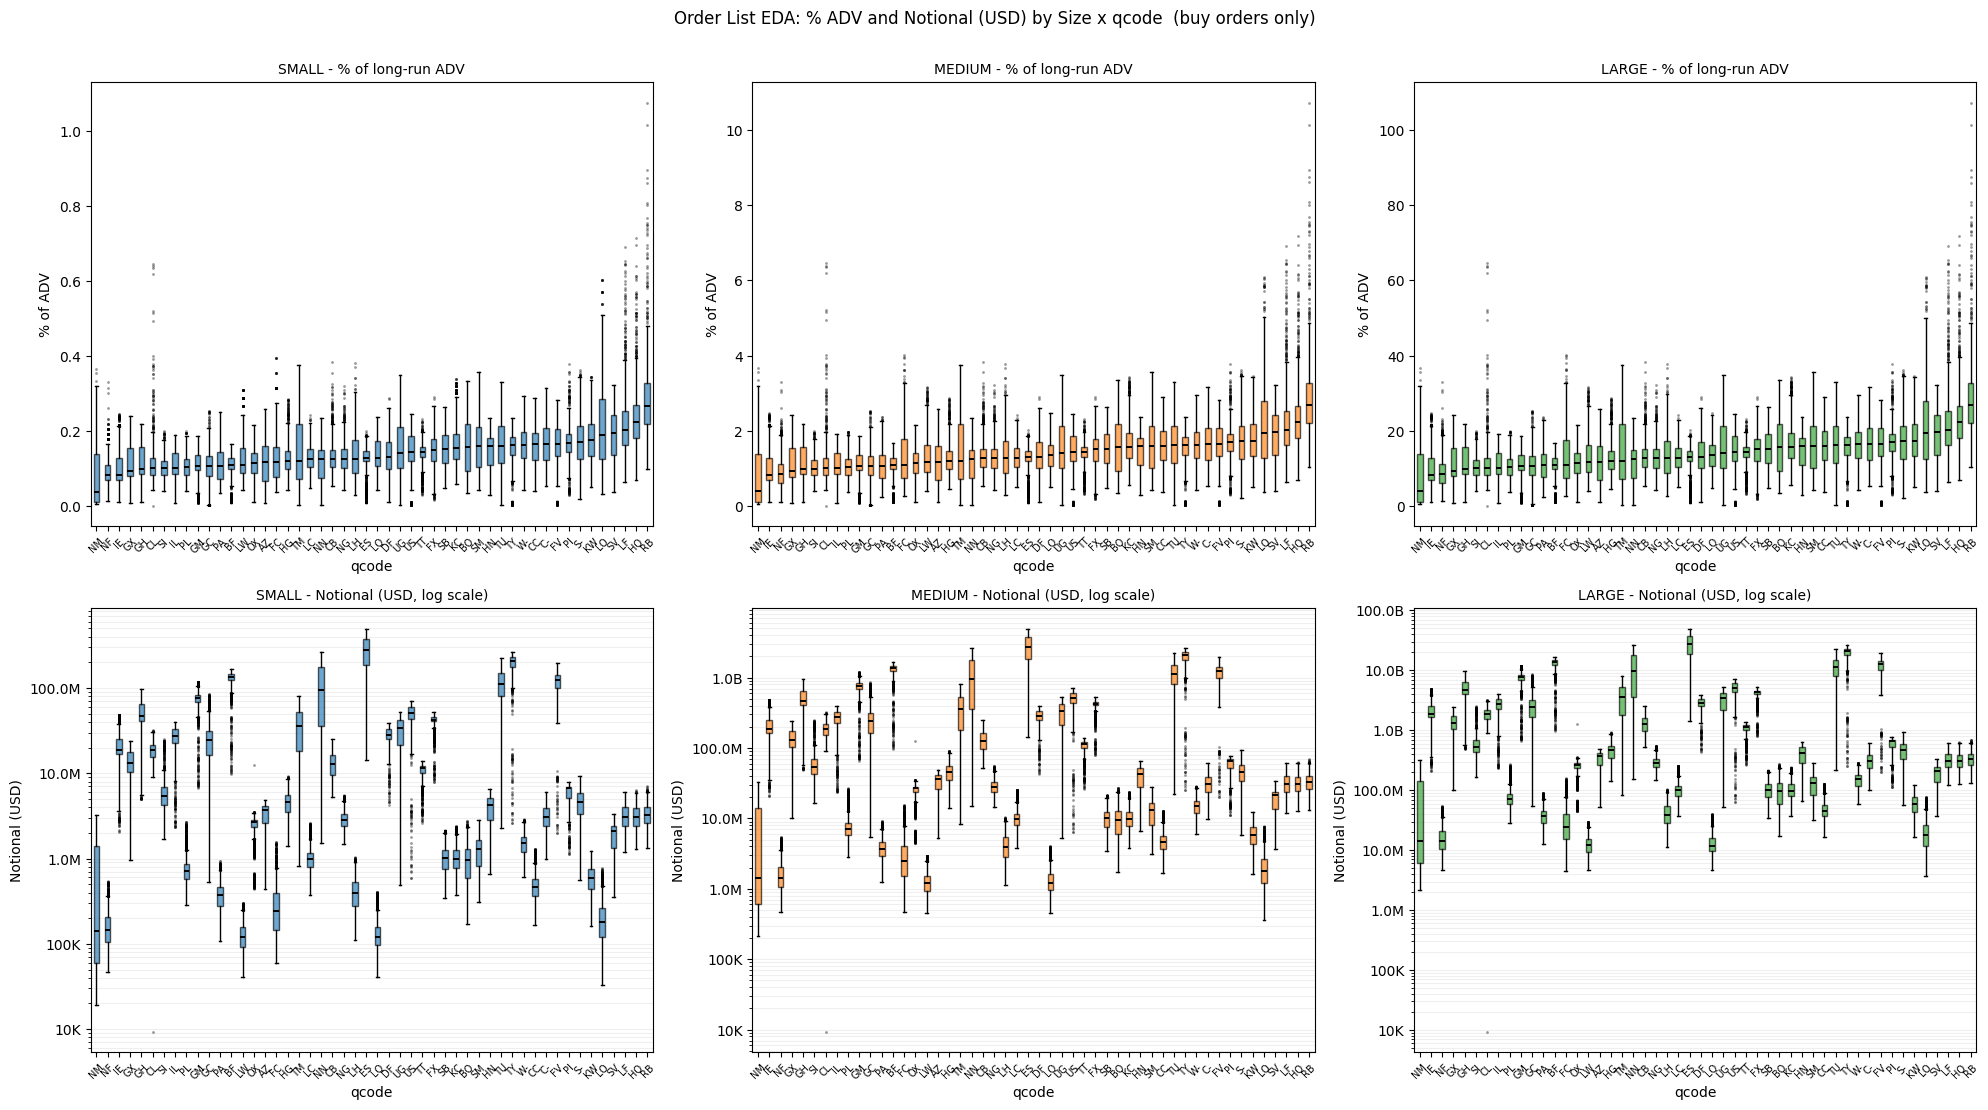

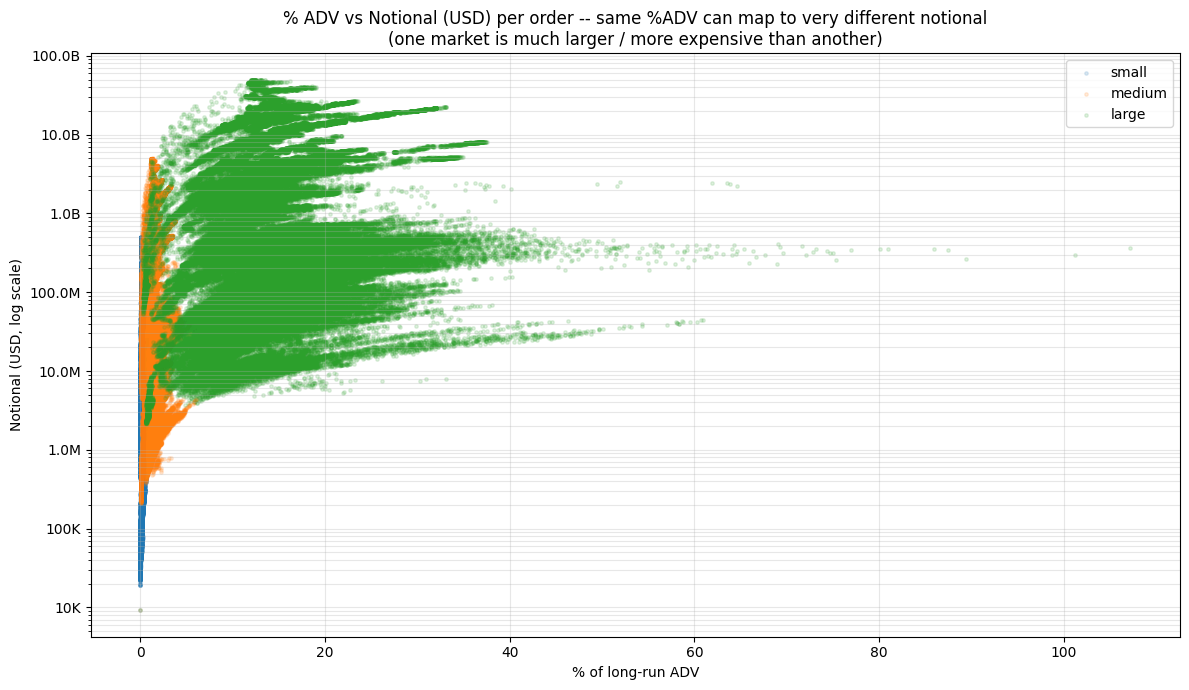

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pl.Config.set_tbl_cols(-1)

# -----------------------------------------------------------------
# 0.  Load & prep
# -----------------------------------------------------------------
print("Loading data ...")
tl = pl.read_csv("data/raw/trade_list.csv")
sm = pl.read_csv("data/raw/security_meta.csv", columns=["security", "qcode"])
qm = pl.read_csv("data/raw/qcode_mapping.csv",
                 columns=["qcode", "description", "exchange", "currency"])
bd = pl.read_csv("data/raw/binned_data.csv",
                 columns=["qcode", "publication_date", "volume", "vwap"])
print(f"  trade_list: {tl.height:,} rows  |  binned_data: {bd.height:,} rows")

# Daily aggregation: total volume + volume-weighted VWAP
daily = (
    bd
    .filter(pl.col("volume").is_not_null() & (pl.col("volume") > 0)
            & pl.col("vwap").is_not_null() & (pl.col("vwap") > 0))
    .group_by(["qcode", "publication_date"])
    .agg(
        pl.col("volume").sum().alias("day_volume"),
        (pl.col("volume") * pl.col("vwap")).sum().alias("_numer"),
    )
    .with_columns((pl.col("_numer") / pl.col("day_volume")).alias("day_vwap"))
    .drop("_numer")
    .rename({"publication_date": "date"})
)

# Long-run ADV per qcode (mean of daily volumes across full binned_data span)
adv_tbl = daily.group_by("qcode").agg(pl.col("day_volume").mean().alias("adv"))

# Helper: sort a df that has a "size" col in [small, medium, large] order
_size_rank = pl.DataFrame({"size": ["small", "medium", "large"], "_rank": [0, 1, 2]})
def sort_by_size(df):
    return df.join(_size_rank, on="size", how="left").sort("_rank").drop("_rank")


# -----------------------------------------------------------------
# FX: fetch daily rates and convert all notionals to USD
# -----------------------------------------------------------------
import yfinance as yf

FX_CACHE = Path("data/raw/fx_rates.csv")

# Tickers that give USD per 1 unit of local currency (direct quote)
DIRECT = {"EUR": "EURUSD=X", "GBP": "GBPUSD=X", "AUD": "AUDUSD=X"}
# Tickers that give local-per-USD (indirect) -> we invert
INDIRECT = {"JPY": "USDJPY=X", "SEK": "USDSEK=X", "SGD": "USDSGD=X"}

if not FX_CACHE.exists():
    print("Downloading FX rates from Yahoo Finance (2015-12 to 2026-05) ...")
    frames = []
    for ccy, ticker in {**DIRECT, **INDIRECT}.items():
        raw = yf.download(ticker, start="2015-12-01", end="2026-05-01",
                          progress=False, auto_adjust=True)
        close = raw["Close"].squeeze()   # yfinance 1.5 returns single-col DF; squeeze -> Series
        df = pd.DataFrame({"date": close.index.astype(str), "usd_per_unit": close.to_numpy(), "currency": ccy})
        if ccy in INDIRECT:
            df["usd_per_unit"] = 1.0 / df["usd_per_unit"]
        frames.append(df)
    fx_pd = pd.concat(frames, ignore_index=True)
    fx_pd.to_csv(FX_CACHE, index=False)
    print(f"  Saved {len(fx_pd):,} rows -> {FX_CACHE}")
else:
    fx_pd = pd.read_csv(FX_CACHE)
    print(f"  Loaded cached FX rates: {len(fx_pd):,} rows")

# Forward-fill gaps (e.g. exchange holidays where FX had no print but futures traded).
# Reindex each currency to a dense daily grid so every calendar day has a rate.
frames_filled = []
for ccy, grp in fx_pd.groupby("currency"):
    grp = grp.set_index(pd.to_datetime(grp["date"])).drop(columns="date")
    grp = grp.reindex(pd.date_range(grp.index.min(), grp.index.max(), freq="D")).ffill()
    grp.index = grp.index.astype(str)
    grp["currency"] = ccy
    frames_filled.append(grp.reset_index().rename(columns={"index": "date"}))
fx_pd_filled = pd.concat(frames_filled, ignore_index=True)

fx = pl.from_pandas(fx_pd_filled).with_columns(pl.col("date").cast(pl.Utf8))
print(f"  FX currencies: {sorted(fx['currency'].unique().to_list())}  (+USD=1.0 passthrough)")


# -----------------------------------------------------------------
# Contract multipliers: quantity x vwap x mult = true local-currency notional
# -----------------------------------------------------------------
# Bond: price is % of face value; mult = face_value / 100
# Equity: price is index level; mult = ccy per index point
# Commodity: mult converts (price-unit x contract-size) to notional
MULT_CSV = Path("data/raw/contract_multipliers.csv")
mult_df = pl.read_csv(MULT_CSV, columns=["qcode", "mult"])
MULT = dict(zip(mult_df["qcode"].to_list(), mult_df["mult"].to_list()))


# Sanity check: every qcode in trade_list has a multiplier
missing_mult = set(tl.join(sm, on="security", how="left")["qcode"].unique().to_list()) - set(MULT)
if missing_mult:
    print(f"  WARNING: no multiplier for qcodes: {missing_mult}")
else:
    print(f"  Multipliers loaded for all {len(MULT)} qcodes.")


# -----------------------------------------------------------------
# Master table
# -----------------------------------------------------------------
master = (
    tl
    .with_columns(
        pl.col("trade_list").str.extract(r"^(small|medium|large)", 0).alias("size"),
    )
    .join(sm,       on="security",        how="left")
    .join(qm,       on="qcode",           how="left")
    .join(daily,    on=["qcode", "date"],  how="left")
    .join(adv_tbl,  on="qcode",           how="left")
    .join(mult_df,  on="qcode",           how="left")
    # join FX on (currency, date)
    .join(fx, on=["currency", "date"], how="left")
    # USD instruments: usd_per_unit is null after join -> fill with 1.0
    .with_columns(pl.col("usd_per_unit").fill_null(1.0))
    .with_columns([
        (pl.col("quantity") / pl.col("day_volume") * 100).alias("pct_of_day_vol"),
        (pl.col("quantity") / pl.col("adv")        * 100).alias("pct_of_adv"),
        # true local-currency notional = qty x price x contract_multiplier
        (pl.col("quantity") * pl.col("day_vwap") * pl.col("mult")).alias("notional_local"),
        # convert to USD
        (pl.col("quantity") * pl.col("day_vwap") * pl.col("mult") * pl.col("usd_per_unit")).alias("notional_usd"),
    ])
)
print(f"\n  master: {master.height:,} rows  |  qcodes: {master['qcode'].n_unique()}  |  "
      f"date range: {master['date'].min()} - {master['date'].max()}")

# Check FX coverage: how many rows still have null notional_usd?
null_usd = master["notional_usd"].null_count()
null_local = master["notional_local"].null_count()
print(f"  notional_usd  nulls: {null_usd:,}  (missing FX or missing VWAP)")
print(f"  notional_local nulls: {null_local:,}  (missing VWAP only)")


# -----------------------------------------------------------------
# 1.  BUY / SELL SYMMETRY
# -----------------------------------------------------------------
print()
print("="*72)
print("PART 1 - Are buy & sell quantities mirror images of each other?")
print("="*72)

sym = (
    master
    .select(["security", "date", "size", "side", "quantity"])
    .pivot(index=["security", "date", "size"], on="side", values="quantity")
    .rename({"buy": "buy_qty", "sell": "sell_qty"})
    .with_columns((pl.col("buy_qty") - pl.col("sell_qty")).alias("diff"))
)

n_total    = sym.height
n_exact    = (sym["diff"] == 0).sum()
n_near     = (sym["diff"].abs() <= 1).sum()
n_mismatch = n_total - n_near

print(f"\n  Combinations (security x date x size): {n_total:,}")
print(f"  Exactly equal  (diff = 0): {n_exact:,}  ({n_exact/n_total*100:.2f}%)")
print(f"  Near-equal (|diff| <= 1):  {n_near:,}   ({n_near/n_total*100:.2f}%)")
print(f"  Mismatch   (|diff|  > 1):  {n_mismatch:,}")

print("\n  Max absolute diff per size bucket:")
print(sort_by_size(
    sym.group_by("size").agg(pl.col("diff").abs().max().alias("max_abs_diff"))
))

if n_mismatch:
    print("\n  Mismatch examples (top 10 by |diff|):")
    print(sym.filter(pl.col("diff").abs() > 1).sort("diff", descending=True).head(10))
else:
    print("\n  All buy quantities exactly equal their sell counterpart.")
    print("  -> Analysis below uses BUY rows only (sells are identical in magnitude).")


# -----------------------------------------------------------------
# 2.  % OF ADV  (buys only)
# -----------------------------------------------------------------
print()
print("="*72)
print("PART 2 - % of ADV traded per order  (buy orders only)")
print("="*72)
print("""
  Two metrics:
    pct_of_adv      = quantity / long-run avg daily volume (full binned_data span)
    pct_of_day_vol  = quantity / that day's actual traded volume
""")

buys = master.filter(pl.col("side") == "buy")

for col, label in [("pct_of_adv", "% of long-run ADV"), ("pct_of_day_vol", "% of single-day volume")]:
    sub = buys.drop_nulls(subset=[col])
    stats = sort_by_size(
        sub.group_by("size").agg([
            pl.len().alias("n"),
            pl.col(col).mean().alias("mean"),
            pl.col(col).median().alias("p50"),
            pl.col(col).quantile(0.25).alias("p25"),
            pl.col(col).quantile(0.75).alias("p75"),
            pl.col(col).min().alias("min"),
            pl.col(col).max().alias("max"),
        ])
    )
    print(f"  -- {label} --")
    print(stats)
    print()


# -----------------------------------------------------------------
# 3.  NOTIONAL VALUE (USD)
# -----------------------------------------------------------------
print("="*72)
print("PART 3 - Notional = quantity x daily VWAP, converted to USD  (buys only)")
print("="*72)

buys_n = buys.drop_nulls(subset=["notional_usd"])

notional_stats = sort_by_size(
    buys_n.group_by("size").agg([
        pl.len().alias("n"),
        pl.col("notional_usd").mean().alias("mean_USD"),
        pl.col("notional_usd").median().alias("p50_USD"),
        pl.col("notional_usd").quantile(0.25).alias("p25_USD"),
        pl.col("notional_usd").quantile(0.75).alias("p75_USD"),
        pl.col("notional_usd").min().alias("min_USD"),
        pl.col("notional_usd").max().alias("max_USD"),
        (pl.col("notional_usd").std() / pl.col("notional_usd").mean()).alias("CoV"),
    ])
)
print("\n  CoV = std/mean: high CoV within a bucket means two orders labelled")
print("  the same size can have very different absolute notional impact.\n")
print(notional_stats)

# Within-large: top-10 USD notional vs bottom-10
print("\n  LARGE orders: top-10 USD notional vs bottom-10 USD notional")
large = buys_n.filter(pl.col("size") == "large").sort("notional_usd", descending=True)
compare = pl.concat([
    large.head(10).with_columns(pl.lit("top-10").alias("group")),
    large.tail(10).with_columns(pl.lit("bot-10").alias("group")),
])
print(compare.select(["group", "qcode", "description", "currency", "date", "quantity",
                      "adv", "day_vwap", "usd_per_unit", "pct_of_adv", "notional_usd"]))


# -----------------------------------------------------------------
# 4.  PER-QCODE BREAKDOWN
# -----------------------------------------------------------------
print()
print("="*72)
print("PART 4 - Per-qcode statistics  (buy orders only, notional in USD)")
print("="*72)

qcode_stats = (
    buys_n
    .drop_nulls(subset=["pct_of_adv"])
    .group_by(["qcode", "description", "exchange", "currency", "size"])
    .agg([
        pl.len().alias("n_orders"),
        pl.col("adv").first().alias("qcode_ADV"),
        pl.col("pct_of_adv").mean().alias("mean_%ADV"),
        pl.col("pct_of_day_vol").mean().alias("mean_%dayVol"),
        pl.col("notional_usd").mean().alias("mean_notional_USD"),
        pl.col("notional_usd").median().alias("median_notional_USD"),
    ])
    .join(_size_rank, on="size", how="left")
    .sort(["_rank", "qcode"])
    .drop("_rank")
)
print()
with pl.Config(tbl_rows=200):
    print(qcode_stats)


# -----------------------------------------------------------------
# 5.  PLOTS
# -----------------------------------------------------------------
sizes  = ["small", "medium", "large"]
colors = {"small": "#1f77b4", "medium": "#ff7f0e", "large": "#2ca02c"}

def _fmt_notional(x, _):
    if x <= 0:
        return "0"
    if x >= 1e9:
        return f"{x/1e9:.1f}B"
    if x >= 1e6:
        return f"{x/1e6:.1f}M"
    if x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Order List EDA: % ADV and Notional (USD) by Size x qcode  (buy orders only)",
             fontsize=12, y=1.005)

for ci, sz in enumerate(sizes):
    sub = buys_n.filter(pl.col("size") == sz)

    # Sort qcodes by their median %ADV
    qcode_order = (
        sub.group_by("qcode")
        .agg(pl.col("pct_of_adv").median().alias("med"))
        .sort("med")["qcode"].to_list()
    )
    data_adv = [sub.filter(pl.col("qcode") == q)["pct_of_adv"].drop_nulls().to_numpy()
                for q in qcode_order]
    data_not = [sub.filter(pl.col("qcode") == q)["notional_usd"].drop_nulls().to_numpy()
                for q in qcode_order]

    # row 0: % of ADV
    ax0 = axes[0][ci]
    bp0 = ax0.boxplot(data_adv, labels=qcode_order, vert=True, patch_artist=True,
                      flierprops=dict(marker=".", markersize=2, alpha=0.4),
                      medianprops=dict(color="k", linewidth=1.4))
    for p in bp0["boxes"]:
        p.set_facecolor(colors[sz]); p.set_alpha(0.65)
    ax0.set_title(f"{sz.upper()} - % of long-run ADV", fontsize=10)
    ax0.set_ylabel("% of ADV"); ax0.set_xlabel("qcode")
    ax0.tick_params(axis="x", labelsize=7, rotation=45)

    # row 1: notional USD
    ax1 = axes[1][ci]
    bp1 = ax1.boxplot(data_not, labels=qcode_order, vert=True, patch_artist=True,
                      flierprops=dict(marker=".", markersize=2, alpha=0.4),
                      medianprops=dict(color="k", linewidth=1.4))
    for p in bp1["boxes"]:
        p.set_facecolor(colors[sz]); p.set_alpha(0.65)
    ax1.set_title(f"{sz.upper()} - Notional (USD, log scale)", fontsize=10)
    ax1.set_ylabel("Notional (USD)"); ax1.set_xlabel("qcode")
    ax1.tick_params(axis="x", labelsize=7, rotation=45)
    ax1.set_yscale("log")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(_fmt_notional))
    ax1.grid(True, which="both", axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# Scatter: %ADV vs notional_usd, coloured by size
fig2, ax = plt.subplots(figsize=(12, 7))
for sz in sizes:
    sub = buys_n.filter(pl.col("size") == sz)
    ax.scatter(sub["pct_of_adv"].to_numpy(),
               sub["notional_usd"].to_numpy(),
               alpha=0.15, s=6, label=sz, color=colors[sz])
ax.set_xlabel("% of long-run ADV")
ax.set_ylabel("Notional (USD, log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_fmt_notional))
ax.set_title("% ADV vs Notional (USD) per order -- same %ADV can map to very different notional\n"
             "(one market is much larger / more expensive than another)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


## Reactor analysis: does forecasting the spread help, on top of forecasting volume?

Simplified redo, comparing just **two** strategies from `execution.py` (both scored as improvement in bps over the static-VWAP baseline, `vwap_roll22`, on the `large_buys` bucket, full history):

- **`adaptive_volume_ols`** -- forecasts volume only, from the single most-recently-completed 5-minute bin.
- **`spread_factor_vol_ols`** -- forecasts volume *and* spread the same way, and schedules to minimise the cost of both.

Three numbers per market: `vol_gain` (how much the volume-only strategy beats the baseline by), `vol_spread_gain` (how much the volume+spread strategy beats the baseline by), and `spread_increment = vol_spread_gain - vol_gain` (the *extra* benefit specifically from adding the spread forecast -- can be negative).

Five plain-English explanatory numbers (all describe the market data itself, not any strategy): **day-to-day spread/volume swings** (`cv_spread`/`cv_volume` -- does the day's average look about the same every day, or does it bounce around?), **spread/volume carry-over** (`spr_ar_rho`/`vol_ar_rho` -- if one 5-minute bin is unusually wide/busy, is the very next bin likely to be too? relevant here specifically because both strategies only ever look at the single most recent bin), and **does busy line up with tight/wide** (`vol_spread_corr`).

Full write-up: **`reports/volume_spread_reactor_analysis.md`**. Source data: `scripts/reactor_simple_analysis.py` -> `data/processed/reactor_simple.csv`.


In [ ]:
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

reactor = pd.read_csv("data/processed/reactor_simple.csv")

print("Biggest reactors overall, ranked by vol_spread_gain:")
print(reactor.sort_values("vol_spread_gain", ascending=False)
      [["qcode", "vol_gain", "vol_spread_gain", "spread_increment", "adv_notional_usd"]]
      .head(10).to_string(index=False))

print()
print("Markets where BOTH strategies do worse than static VWAP:")
neg = reactor[(reactor.vol_gain <= 0) & (reactor.vol_spread_gain <= 0)]
print(neg.sort_values("vol_spread_gain")[["qcode", "vol_gain", "vol_spread_gain"]].to_string(index=False))

print()
print("KW -- volume forecasting works, but adding a spread forecast makes it much worse:")
print(reactor[reactor.qcode == "KW"][["qcode", "vol_gain", "vol_spread_gain", "spread_increment"]].to_string(index=False))


In [ ]:
import matplotlib.pyplot as plt

# Extra value of spread forecasting vs. spread's own persistence and day-to-day swings
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sizes = 50 + 900 * reactor["cv_spread"]
sc = ax.scatter(reactor["spr_ar_rho"], reactor["spread_increment"], s=sizes,
                 c=reactor["cv_spread"], cmap="YlOrBr", edgecolors="k", linewidths=0.4, alpha=0.85)
for _, r in reactor.iterrows():
    if r["spread_increment"] > 0.01 or r["qcode"] in ("LW", "SB", "LO", "KW"):
        ax.annotate(r["qcode"], (r["spr_ar_rho"], r["spread_increment"]), fontsize=8,
                    xytext=(4, 3), textcoords="offset points")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("cv_spread (day-to-day spread swings) -- also point size")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("spr_ar_rho  (does a wide bin tend to be followed by another wide bin?)")
ax.set_ylabel("spread_increment  (extra bps gained by forecasting spread, on top of volume)")
ax.set_title("Extra value of spread forecasting vs.\nspread's persistence and day-to-day swings")
fig.tight_layout(); plt.show()


In [ ]:
import numpy as np
from scipy import stats

def simple_ols(y, X):
    Xc = np.column_stack([np.ones(len(X)), X.to_numpy()])
    beta, *_ = np.linalg.lstsq(Xc, y.to_numpy(), rcond=None)
    fitted = Xc @ beta
    ss_res = ((y.to_numpy() - fitted) ** 2).sum()
    ss_tot = ((y.to_numpy() - y.mean()) ** 2).sum()
    return dict(zip(["intercept"] + list(X.columns), beta)), 1 - ss_res / ss_tot

# Does spread_increment go up with the market's own spread swings + carry-over?
for label, sub in [("All 50 markets", reactor), ("Excluding NF", reactor[reactor.qcode != "NF"])]:
    coefs, r2 = simple_ols(sub["spread_increment"], sub[["cv_spread", "spr_ar_rho"]])
    print(f"--- {label} (n={len(sub)}) ---")
    print(f"  spread_increment = {coefs['intercept']:.4f} + {coefs['cv_spread']:.4f} x cv_spread "
          f"+ {coefs['spr_ar_rho']:.4f} x spr_ar_rho   (R-squared = {r2:.2f})")

rho_all, _ = stats.pearsonr(reactor["cv_spread"], reactor["spread_increment"])
rho_no_nf, _ = stats.pearsonr(reactor[reactor.qcode != "NF"]["cv_spread"], reactor[reactor.qcode != "NF"]["spread_increment"])
rho_vs, _ = stats.pearsonr(reactor["vol_spread_corr"], reactor["spread_increment"])
print(f"\ncorrelation(spread swings, spread_increment): all 50 = {rho_all:+.2f}, excl. NF = {rho_no_nf:+.2f}")
print(f"correlation(does-busy-mean-tight-spread, spread_increment) = {rho_vs:+.2f}  (essentially nothing)")


**Findings.**

- **Volume-only reactors** (spread adds little): `LO`, `LW`, `SB`. `LO` is a puzzle -- its spread swings a lot (2nd-highest in the dataset) and carries over normally, yet gets *no* benefit from spread forecasting.
- **Volume+spread reactors**: `NM`, `PA`, `RB`, `LQ`, `LF`, `HO`, `CC` -- all have real day-to-day spread swings (not just noise) plus spreads that carry over bin-to-bin, which is exactly what an OLS-style, most-recent-bin forecast can exploit.
- **Negative reactors**: `SI`, `CL`, `NN`, `HG`, `GC` (both strategies below the static baseline) -- all very liquid, tight-spread markets with little room to improve; `ES`/`GC` land almost exactly at zero. `KW` is a separate, unexplained case: volume forecasting works, but adding a spread forecast makes things *much* worse.
- **Biggest reactor overall**: `NF`, by a factor of ~9x over the next name -- it's the most extreme market in the dataset on both spread width and spread swings.
- **Does the story hold up?** A simple straight-line fit of `spread_increment` on spread swings + carry-over explains 17% of the variation across all 50 markets, but only 6% once `NF` is excluded, and the correlation drops from +0.41 to +0.25. `NF` is doing most of the work -- the named examples above are real and individually true, but with only 50 markets and one dominant outlier, this can't be certified as a general rule.
